# Análisis de Sentimientos con Deep Learning: Paris 2024


Este proyecto aborda uno de los desafíos clásicos del Procesamiento del Lenguaje Natural (NLP): la clasificación de sentimientos en textos no estructurados y ruidosos, extraídos directamente de comentarios de YouTube sobre los Juegos Olímpicos.

Más allá de la simple implementación de código, el objetivo central de este notebook es realizar un estudio comparativo riguroso entre diferentes arquitecturas de redes neuronales recurrentes. Analizaremos cómo evoluciona la capacidad de aprendizaje desde una RNN Simple, pasando por una LSTM Bidireccional, hasta experimentar con arquitecturas complejas tipo Seq2Seq (Encoder-Decoder).

A lo largo de las siguientes fases, gestionaremos el ciclo de vida completo del dato: desde la limpieza y tokenización, pasando por el manejo del desbalance de clases, hasta la evaluación crítica de métricas para determinar qué arquitectura comprende mejor la opinión pública.

# Fase 1: Recolección de Comentarios de YouTube

El  primer  paso  en  este  proceso  es  recolectar  datos.  Aquí,  utilizarás  la API  de YouTube  Data  v3 para  obtener  comentarios  de  un  vídeo  sobre  los  Juegos Olímpicos.  Es  fundamental  que  justifiques  la  cantidad  de  comentarios  que decidas recolectar, considerando la representatividad de la muestra y el tiempo de procesamiento.

Objetivo: Aprender  a  trabajar  con  datos  reales  utilizando  una  API  externa,  y comenzar a preparar un conjunto de datos que utilizarás en las fases posteriores. 

In [ ]:
import os
import pandas as pd
import re
import numpy as np
import warnings
import time
import torch

from googleapiclient.discovery import build
from googleapiclient.errors import HttpError

from transformers import pipeline
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from wordcloud import WordCloud, STOPWORDS
import matplotlib.dates as mdates


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional, RepeatVector
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical



warnings.filterwarnings('ignore')


In [2]:
MAX_VOCAB_SIZE = 5000
MAX_SEQUENCE_LEN = 100
EMBEDDING_DIM = 100

API_KEY = os.getenv("YOUTUBE_API_KEY")


In [3]:
videos_dats_dict = {
    "Sydney McLaughlin-Levrone 👑 - Women's 400m hurdles Olympic champion! | #Paris2024 Highlights": "V3aeiR7plQw",    # Sentimiento: Admiracion - positivismo
    "The Coolest Olympic Athlete? ‘Gearless’ Turkish shooter Yusuf Dikec goes viral 🇹🇷😎 | #Paris2024": "EHnNJKSE87Y",  # Sentimiento: Humor - Viral positivo
    "An UNBELIEVABLE Final in Paris! | Men's Football Gold Medal Game | #Paris2024 Highlights":"fZl_LVU7a18",          # Sentimiento: Rivalidad / Pasión Nacional
    "Noah Lyles takes gold! Men's 100m Final! 🇺🇸🔥🥇 | #Paris2024 highlights": "gW0y6K6c6Jw"                            # Sentimiento: Arrogancia vs Confianza (Debate)
}

In [4]:
def fetch_youtube_comments(videos_dict):
    try:
        youtube = build('youtube', 'v3', developerKey=API_KEY)
    except Exception as e:
        print(f"Error initializing YouTube API client: {e}")
        return pd.DataFrame()
    data_list = []

    for etiqueta, video_id in videos_dict.items():
        print(f"Fetching comments for video: {etiqueta}, ID: {video_id}")
        count_video = 0
        next_page_token = None

        while True:
            try:
                request = youtube.commentThreads().list(
                    part="snippet",
                    videoId=video_id,
                    maxResults=100,
                    pageToken=next_page_token,
                    textFormat="plainText"
                )
                response = request.execute()
                for item in response.get("items", []):
                    snippet = item["snippet"]["topLevelComment"]["snippet"]
                    data_list.append({
                        "video_id": video_id,
                        "video_label": etiqueta,
                        "text": snippet.get("textDisplay"),
                        "published_at": snippet.get("publishedAt"),
                        "like_count": snippet.get("likeCount"),
                    })
                    count_video += 1
                if count_video %500 == 0:
                    print(f"Fetched {count_video} comments for video ID: {video_id}")
                next_page_token = response.get("nextPageToken")
                if not next_page_token:
                    break # No more pages / comments
                time.sleep(0.5)  # To respect rate limits
            except HttpError as e:
                if e.resp.status == 403:
                    print("Limit reached or access forbidden. Waiting before retrying...")
                    return pd.DataFrame(data_list)
                elif e.resp.status == 404:
                    print(f"Video not found: {video_id}, or comments disabled.")
                    break
                else:
                    print(f"HTTP error {e.resp.status} occurred: {e.content}")
                    break
            print(f"Total comments fetched for video ID {video_id}: {count_video}")
    return pd.DataFrame(data_list)

In [8]:
df_raw_comments = fetch_youtube_comments(videos_dats_dict)
print(f"Total comments fetched across all videos: {len(df_raw_comments)}")
df_raw_comments.to_csv("olympic_youtube_comments_raw.csv", index=False)

Fetching comments for video: Sydney McLaughlin-Levrone 👑 - Women's 400m hurdles Olympic champion! | #Paris2024 Highlights, ID: V3aeiR7plQw
Total comments fetched for video ID V3aeiR7plQw: 100
Total comments fetched for video ID V3aeiR7plQw: 200
Total comments fetched for video ID V3aeiR7plQw: 300
Fetching comments for video: The Coolest Olympic Athlete? ‘Gearless’ Turkish shooter Yusuf Dikec goes viral 🇹🇷😎 | #Paris2024, ID: EHnNJKSE87Y
Total comments fetched for video ID EHnNJKSE87Y: 100
Total comments fetched for video ID EHnNJKSE87Y: 200
Total comments fetched for video ID EHnNJKSE87Y: 300
Total comments fetched for video ID EHnNJKSE87Y: 400
Fetched 500 comments for video ID: EHnNJKSE87Y
Total comments fetched for video ID EHnNJKSE87Y: 500
Total comments fetched for video ID EHnNJKSE87Y: 600
Total comments fetched for video ID EHnNJKSE87Y: 700
Total comments fetched for video ID EHnNJKSE87Y: 800
Total comments fetched for video ID EHnNJKSE87Y: 900
Fetched 1000 comments for video ID: 

In [5]:
df_raw = pd.read_csv("olympic_youtube_comments_raw.csv")
df_raw.head()

,video_id,video_label,text,published_at,like_count
0,V3aeiR7plQw,Sydney McLaughlin-Levrone 👑 - Women's 400m hur...,Watch all the #Paris2024 🏃 Athletics action ➡ ...,2024-08-08T20:36:38Z,29
1,V3aeiR7plQw,Sydney McLaughlin-Levrone 👑 - Women's 400m hur...,It’s insane who the four …\nActually five grea...,2025-12-26T21:17:44Z,0
2,V3aeiR7plQw,Sydney McLaughlin-Levrone 👑 - Women's 400m hur...,Bol destroyed😊,2025-11-27T15:52:22Z,1
3,V3aeiR7plQw,Sydney McLaughlin-Levrone 👑 - Women's 400m hur...,Wow Great❤,2025-11-16T09:52:41Z,0
4,V3aeiR7plQw,Sydney McLaughlin-Levrone 👑 - Women's 400m hur...,HGH jaws.,2025-11-13T20:54:58Z,0


In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6104 entries, 0 to 6103
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   video_id      6104 non-null   object
 1   video_label   6104 non-null   object
 2   text          6099 non-null   object
 3   published_at  6104 non-null   object
 4   like_count    6104 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 238.6+ KB


In [7]:
df_raw.describe()

,like_count
count,6104.000000
mean,55.601737
std,882.837460
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,51378.000000


# Fase  2:  Clasificación  de  Sentimientos  con  DistilBERT

Una vez que hayas recolectado los comentarios, aplicarás el modelo DistilBERT para clasificar cada uno como positivo o negativo. Este modelo ya está preentrenado y es eficiente para la clasificación de texto en tareas como análisis de sentimientos. Al final de  esta  fase,  deberás  almacenar los resultados y visualizar la distribución de los sentimientos.


Objetivo: Familiarizarte con modelos preentrenados y aplicar aprendizaje transferido en un contexto real, categorizando automáticamente grandes volúmenes de texto

In [8]:
# eliminar filas con texto nulo, modo str y eliminar saltos de línea
df_raw = df_raw.dropna(subset=['text'])
df_raw['text'] = df_raw['text'].astype(str).str.replace('\n', ' ').str.strip()
df_raw

,video_id,video_label,text,published_at,like_count
0,V3aeiR7plQw,Sydney McLaughlin-Levrone 👑 - Women's 400m hur...,Watch all the #Paris2024 🏃 Athletics action ➡ ...,2024-08-08T20:36:38Z,29
1,V3aeiR7plQw,Sydney McLaughlin-Levrone 👑 - Women's 400m hur...,It’s insane who the four … Actually five great...,2025-12-26T21:17:44Z,0
2,V3aeiR7plQw,Sydney McLaughlin-Levrone 👑 - Women's 400m hur...,Bol destroyed😊,2025-11-27T15:52:22Z,1
3,V3aeiR7plQw,Sydney McLaughlin-Levrone 👑 - Women's 400m hur...,Wow Great❤,2025-11-16T09:52:41Z,0
4,V3aeiR7plQw,Sydney McLaughlin-Levrone 👑 - Women's 400m hur...,HGH jaws.,2025-11-13T20:54:58Z,0
...,...,...,...,...,...
6099,gW0y6K6c6Jw,Noah Lyles takes gold! Men's 100m Final! 🇺🇸🔥🥇 ...,Does the head has the priority on the foot?,2024-08-04T22:37:36Z,1
6100,gW0y6K6c6Jw,Noah Lyles takes gold! Men's 100m Final! 🇺🇸🔥🥇 ...,Jamaica WE HAVE A PROBLEM....,2024-08-04T22:23:21Z,0
6101,gW0y6K6c6Jw,Noah Lyles takes gold! Men's 100m Final! 🇺🇸🔥🥇 ...,They measure the head,2024-08-04T22:18:28Z,0
6102,gW0y6K6c6Jw,Noah Lyles takes gold! Men's 100m Final! 🇺🇸🔥🥇 ...,Jamaica won the race by the leg kindly,2024-08-04T22:11:14Z,19


In [9]:
device = 0 if torch.cuda.is_available() else -1
print(f"Usando dispositivo: {'GPU 🚀' if device==0 else 'CPU'}")

Usando dispositivo: CPU


Elegimos el modelo **distilbert-base-multilingual-cased-sentiments-student** de la librería `transformers`, ya que es un modelo ligero y eficiente, ideal para tareas de clasificación de sentimientos en múltiples idiomas (multilingüe). Su arquitectura distilada permite un rendimiento rápido sin sacrificar significativamente la precisión, lo que lo hace adecuado para procesar grandes volúmenes de comentarios de YouTube de manera efectiva.
Al analizar videos de los Juegos Olímpicos, es probable que los comentarios provengan de una audiencia global, por lo que un modelo multilingüe es esencial para capturar con precisión los matices del sentimiento en diferentes idiomas. Además, este modelo ha sido entrenado específicamente para tareas de análisis de sentimientos, lo que garantiza que pueda identificar correctamente las emociones expresadas en los comentarios, ya sean positivas, negativas o neutrales.


Configuramos los parametros **truncation=True** y **max_length=512** debido a las restricciones de longitud de entrada del modelo DistilBERT. Estos modelos tienen un límite físico de atencional posicional de 512 tokens (palabras o subpalabras). Al establecer `truncation=True`, aseguramos que cualquier comentario que exceda este límite sea truncado adecuadamente, evitando errores durante la inferencia. Esto es crucial para mantener la integridad del procesamiento y garantizar que el modelo pueda manejar todos los comentarios sin problemas, optimizando así el análisis de sentimientos.



In [10]:
classifier = pipeline(
    "sentiment-analysis",
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    truncation=True,
    max_length=512,
    device=device
)

Device set to use cpu


Clasificando sentimientos en positivo, negativo o neutral usando DistilBERT

In [11]:
tqdm.pandas()
df_raw['sentiment_distilbert'] = df_raw['text'].progress_apply(lambda x: classifier(x)[0]['label'])
print("Distribución de Sentimientos detectada:")
print(df_raw['sentiment_distilbert'].value_counts())

df_raw.to_csv("olympic_youtube_comments_with_sentiments.csv", index=False)

100%|██████████| 6099/6099 [01:36<00:00, 63.39it/s]

Distribución de Sentimientos detectada:
sentiment_distilbert
positive    3803
negative    2039
neutral      257
Name: count, dtype: int64


# Fase 3: Limpieza y Análisis Exploratorio de los Datos

En esta fase, primero limpiarás los datos eliminando cualquier información irrelevante (enlaces, emojis, caracteres especiales, etc.). Luego, realizarás un análisis exploratorio de los datos limpios, evaluando la distribución de los sentimientos y la longitud de los comentarios. También deberás explorar posibles correlaciones entre la longitud del comentario y el sentimiento asociado.

Objetivo: Mejorar la calidad de los datos eliminando ruido, y obtener un mejor entendimiento de las características generales de los comentarios antes de construir los modelos.

In [12]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [13]:
df_with_sentiments = pd.read_csv("olympic_youtube_comments_with_sentiments.csv")
df_with_sentiments['published_at'] = pd.to_datetime(df_with_sentiments['published_at'])
df_with_sentiments["clean_text"] = df_with_sentiments["text"].apply(clean_text)
df_with_sentiments["word_count"] = df_with_sentiments["clean_text"].apply(lambda x: len(x.split()))

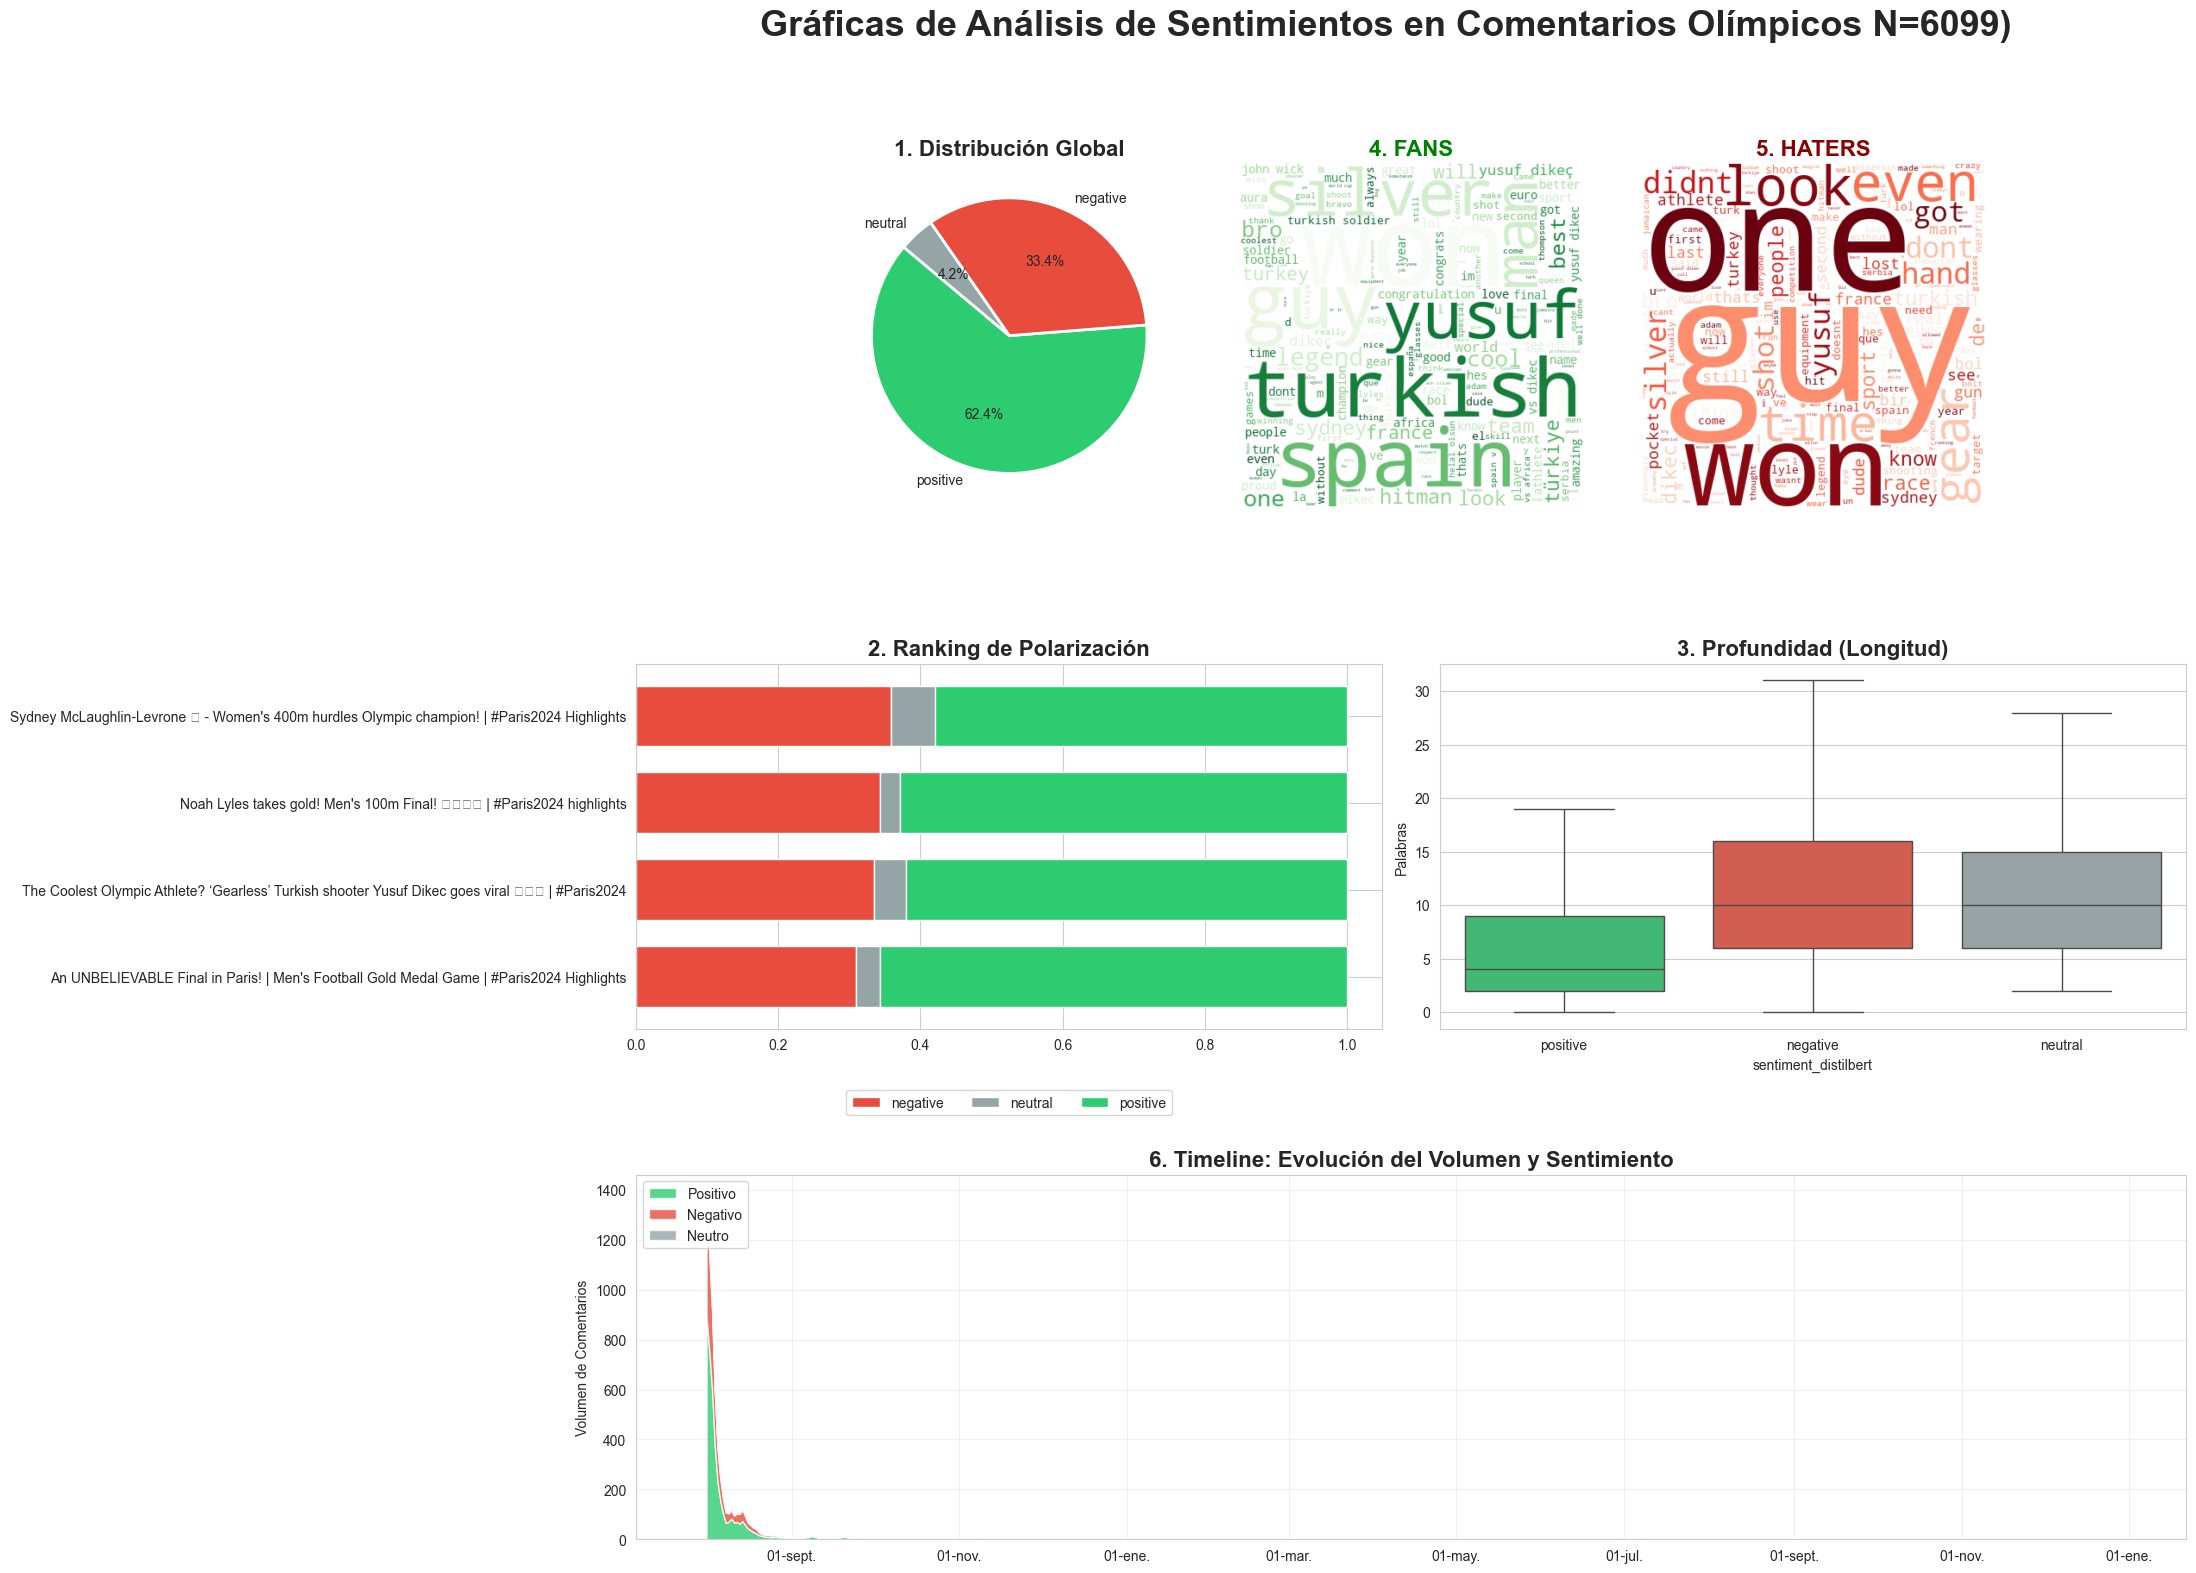

In [14]:
plt.rcParams['figure.figsize'] = (20, 18)
sns.set_style("whitegrid")
colores = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#95a5a6'}
stopwords_set = set(STOPWORDS)
stopwords_set.update(["video", "olympics", "paris", "game", "gold", "medal", "olympic", "match", "win", "winner"])

fig = plt.figure(figsize=(20, 18))
gs = gridspec.GridSpec(3, 8, figure=fig, hspace=0.4, wspace=0.4)
fig.suptitle(f"Gráficas de Análisis de Sentimientos en Comentarios Olímpicos N={len(df_with_sentiments)})", fontsize=26, fontweight='bold', y=0.96)

# Distribución Global de Sentimientos
ax1 = fig.add_subplot(gs[0, 1:3])
conteo = df_with_sentiments['sentiment_distilbert'].value_counts()
ax1.pie(conteo, labels=conteo.index, autopct='%1.1f%%', startangle=140,
        colors=[colores.get(x, '#333') for x in conteo.index], wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('1. Distribución Global', fontsize=16, fontweight='bold')

# Nube Positiva
ax4 = fig.add_subplot(gs[0, 3:5])
text_pos = " ".join(df_with_sentiments[df_with_sentiments['sentiment_distilbert'] == 'positive']['clean_text'])
if len(text_pos) > 0:
    wc_pos = WordCloud(stopwords=stopwords_set, background_color="white", colormap="Greens", height=400, width=400).generate(text_pos)
    ax4.imshow(wc_pos, interpolation='bilinear')
    ax4.set_title('4. FANS', fontsize=16, fontweight='bold', color='green')
ax4.axis("off")

# Nube Negativa
ax5 = fig.add_subplot(gs[0, 5:7])
text_neg = " ".join(df_with_sentiments[df_with_sentiments['sentiment_distilbert'] == 'negative']['clean_text'])
if len(text_neg) > 0:
    wc_neg = WordCloud(stopwords=stopwords_set, background_color="white", colormap="Reds", height=400, width=400).generate(text_neg)
    ax5.imshow(wc_neg, interpolation='bilinear')
    ax5.set_title('5. HATERS', fontsize=16, fontweight='bold', color='darkred')
ax5.axis("off")

# Ranking
ax2 = fig.add_subplot(gs[1, 0:4])
ct = pd.crosstab(df_with_sentiments['video_label'], df_with_sentiments['sentiment_distilbert'], normalize='index')
ct = ct.sort_values('negative', ascending=True)
ct.plot(kind='barh', stacked=True, color=[colores.get(x, '#333') for x in ct.columns], ax=ax2, edgecolor='white', width=0.7)
ax2.set_title('2. Ranking de Polarización', fontsize=16, fontweight='bold')
ax2.set_ylabel('')
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

# Boxplot
ax3 = fig.add_subplot(gs[1, 4:8])
sns.boxplot(x='sentiment_distilbert', y='word_count', data=df_with_sentiments, showfliers=False, ax=ax3, palette=colores)
ax3.set_title('3. Profundidad (Longitud)', fontsize=16, fontweight='bold')
ax3.set_ylabel('Palabras')

# Serie Temporal
ax6 = fig.add_subplot(gs[2, :])

# Preparamos datos globales por día
timeline_global = df_with_sentiments.groupby([pd.Grouper(key='published_at', freq='D'), 'sentiment_distilbert']).size().unstack(fill_value=0)
timeline_smooth = timeline_global.rolling(window=3, min_periods=1).mean()

if not timeline_smooth.empty:
    ax6.stackplot(timeline_smooth.index,
                    timeline_smooth.get('positive', 0),
                    timeline_smooth.get('negative', 0),
                    timeline_smooth.get('neutral', 0),
                    labels=['Positivo', 'Negativo', 'Neutro'],
                    colors=[colores['positive'], colores['negative'], colores['neutral']],
                    alpha=0.8)

    ax6.set_title('6. Timeline: Evolución del Volumen y Sentimiento', fontsize=16, fontweight='bold')
    ax6.set_ylabel('Volumen de Comentarios')
    ax6.legend(loc='upper left')
    ax6.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax6.grid(True, alpha=0.3)

plt.show()

### Conclusiones del Análisis Exploratorio de Datos (EDA) de todos los videos combinados:

El análsis de sentimientos realizado sobre los comentarios de los videos de los Juegos Olímpicos revela una amplia respuesta positiva por parte de la audiencia **62%**, pero existe también una proporción de comentarios negativos **38%** que no debe ser ignorada. La distribución de sentimientos indica que, aunque la mayoría de los espectadores expresan entusiasmo y apoyo, una parte significativa manifiesta críticas o descontento.


### WordClouds
- WordCloud Positivos: Destaca por adjetivos y nombres propios indicando un lenguaje de celebración y admiración.
- WordCloud Negativos: Destacan los sustantivos técnicos y morales indicando críticas específicas y juicios de valor.
- La negatividad no proviene del desinterés, si no de un exceso de involucramiento con la justicia deportiva (o lo que se percibe como tal).

###  Ranking de polarización
Este gráfico de barras apiladas y normalizadas nos permite comparar la "salud" de la conversación independientemente del volumen total de comentarios. Observamos que ciertos videos, como el de la final de fútbol España vs Francia, presentan una polarización más marcada con un mayor porcentaje de comentarios negativos en comparación con otros videos más neutrales o positivos. Esto sugiere que los temas controvertidos o las decisiones arbitrales generan más debate y división entre los espectadores.
En cambio, videos con momentos destacados o celebraciones tienden a tener una mayor proporción de comentarios positivos, reflejando la naturaleza emocional y festiva del evento.

- Zona de consenso: Videos como el de Sydney McLaughlin muestran una abrumadora mayoría de comentarios positivos, indicando un consenso claro entre los espectadores sobre la excelencia deportiva.
- Zona de conflicto: En cambio, videos como la final de fútbol España vs Francia exhiben una mayor proporción de comentarios negativos, reflejando desacuerdos y controversias entre los espectadores y rivalidades nacionales.

### Profundidad (Longitud de comentarios por sentimiento)
La mediana de longitud (número de palabras) de los comentarios negativos (10) es visiblemente superios a la de los comentarios positivos (4). Esto sugiere que los usuarios tienden a elaborar más sus críticas o quejas, mientras que los comentarios positivos suelen ser más breves y directos. Esta diferencia en la longitud puede reflejar la naturaleza emocional de los comentarios negativos, que a menudo requieren más contexto para expresar insatisfacción o desacuerdo.


### Linea de tiempo de sentimientos
El volumen de comentarios positivos parece tener un pico agudo duraante el evento y decae rápidamente indicando que la alegría es efímera. En contraste, los comentarios negativos muestran un patrón más sostenido, sugiriendo que las críticas y quejas persisten más allá del evento inmediato.
Esto se puede interpretar como que la emoción positiva es momentánea, mientras que las preocupaciones o insatisfacciones tienden a mantenerse en el tiempo.


Bloque 2 analisis individual por video

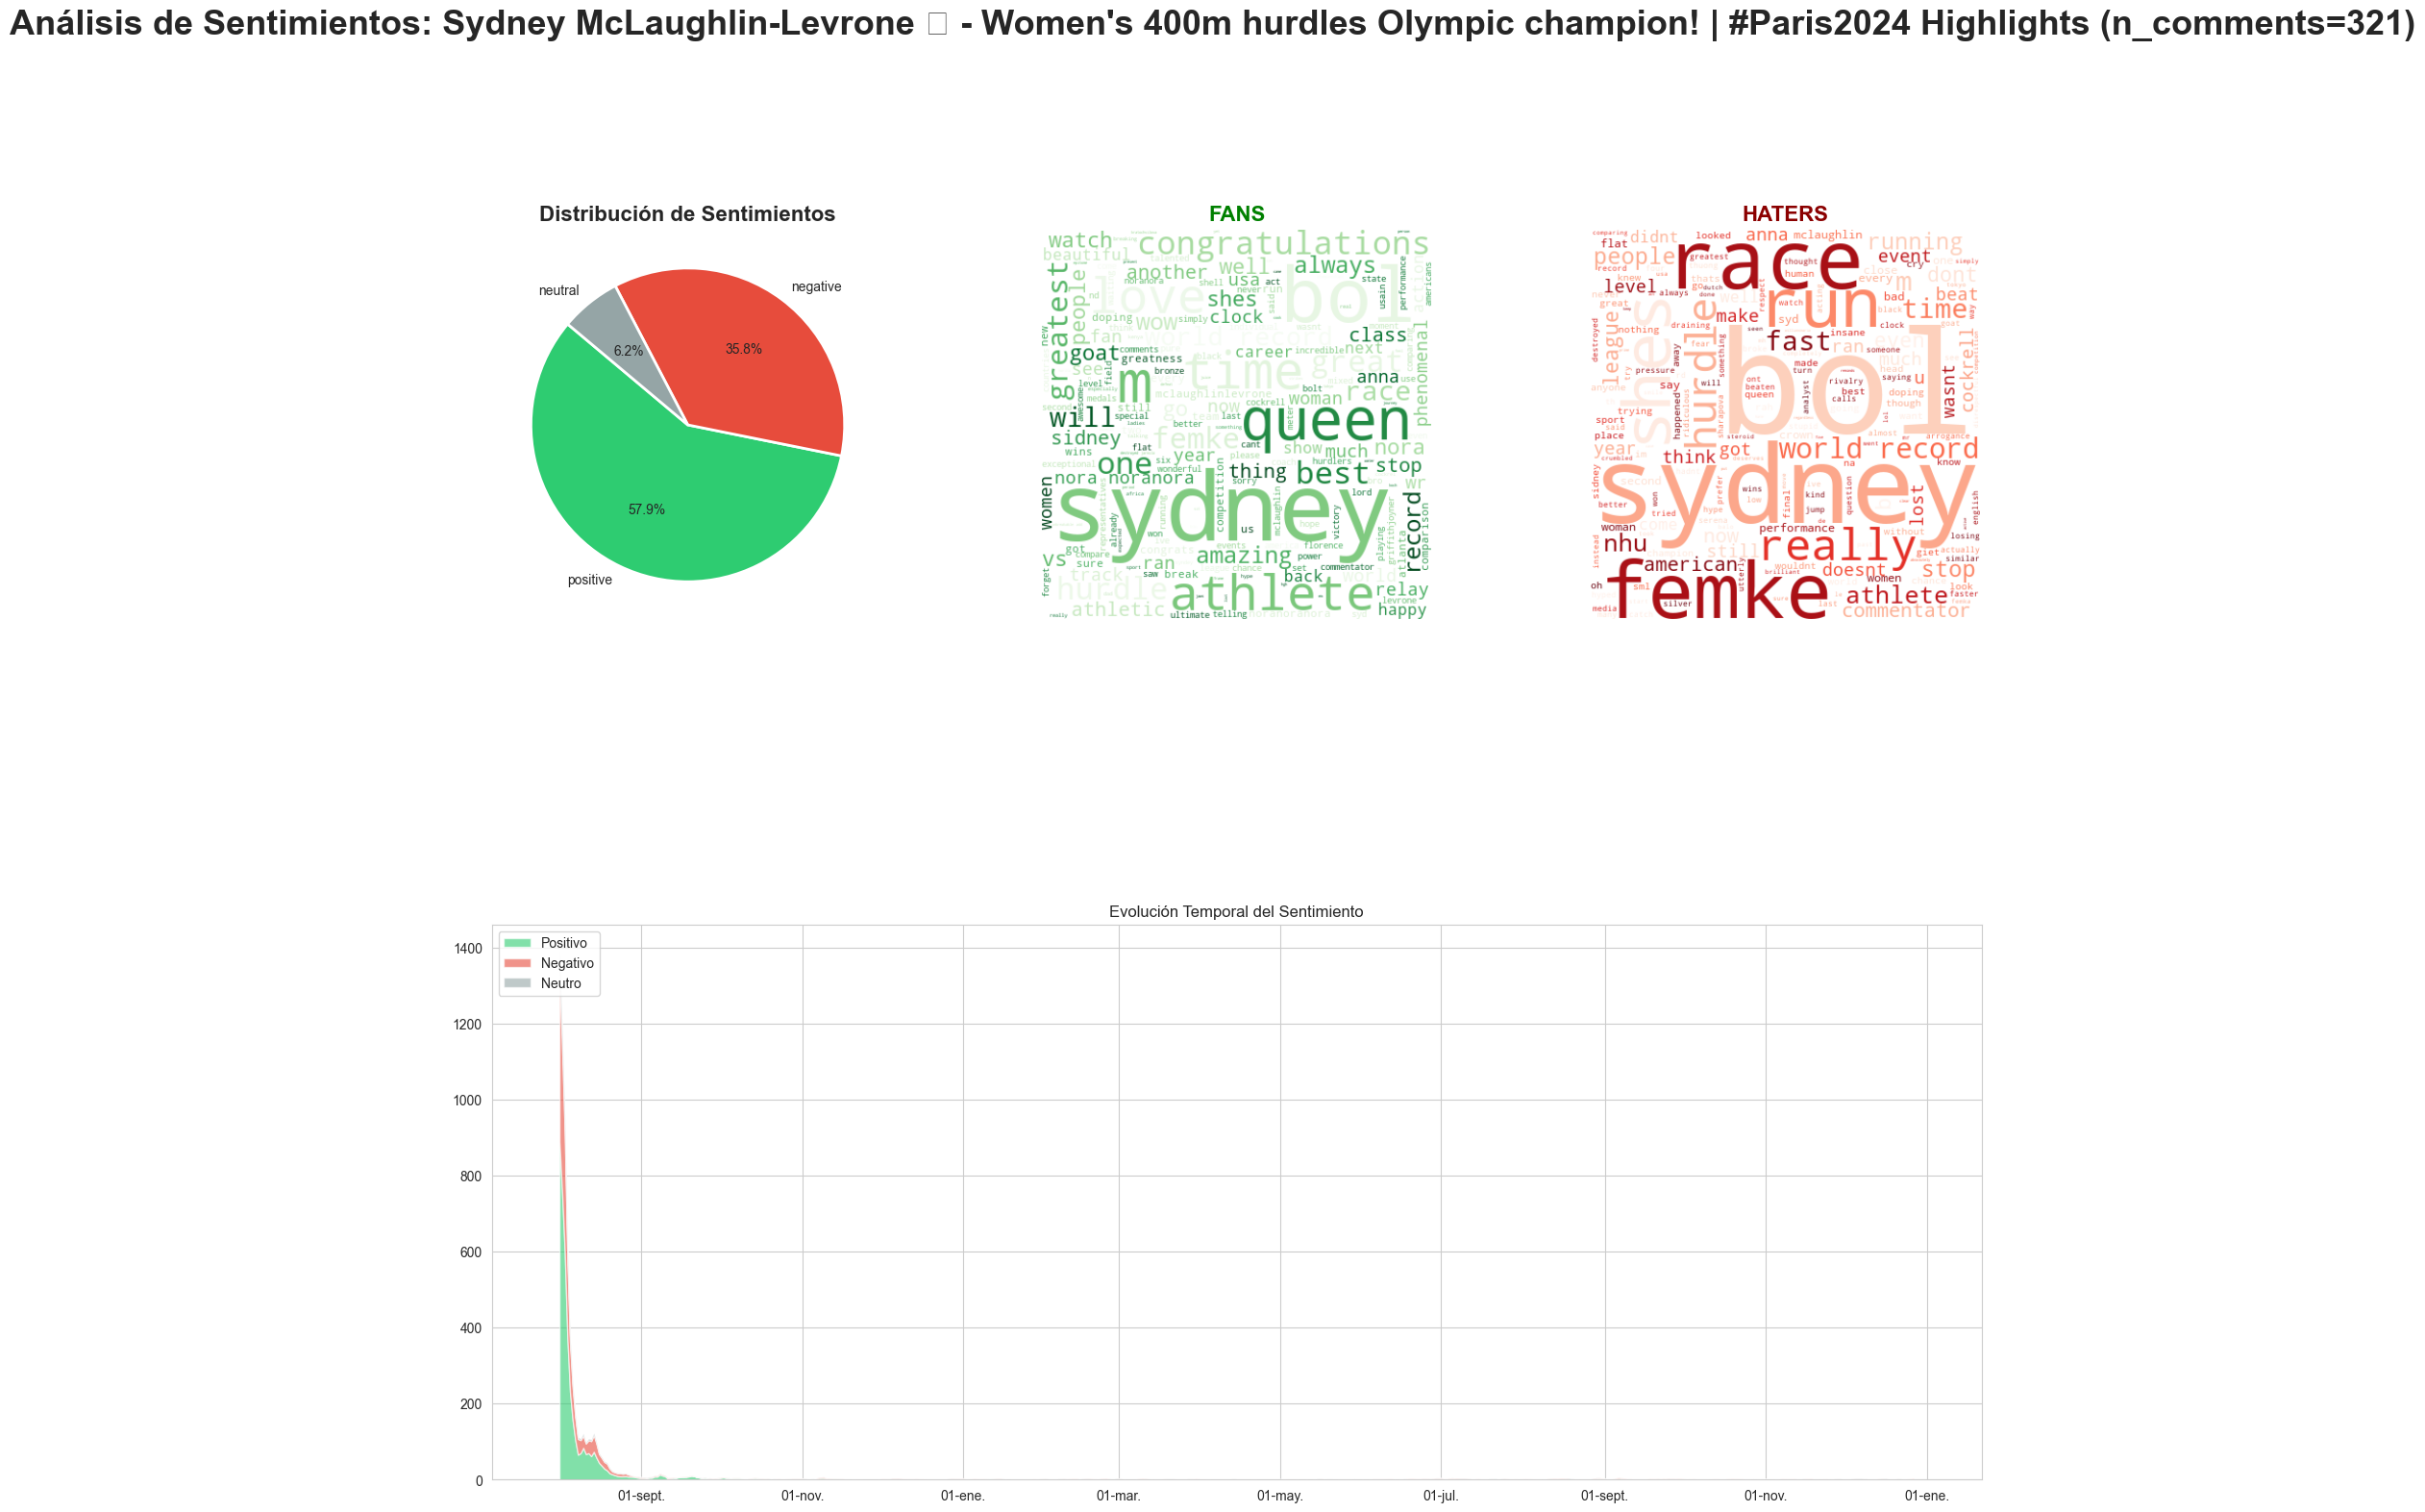

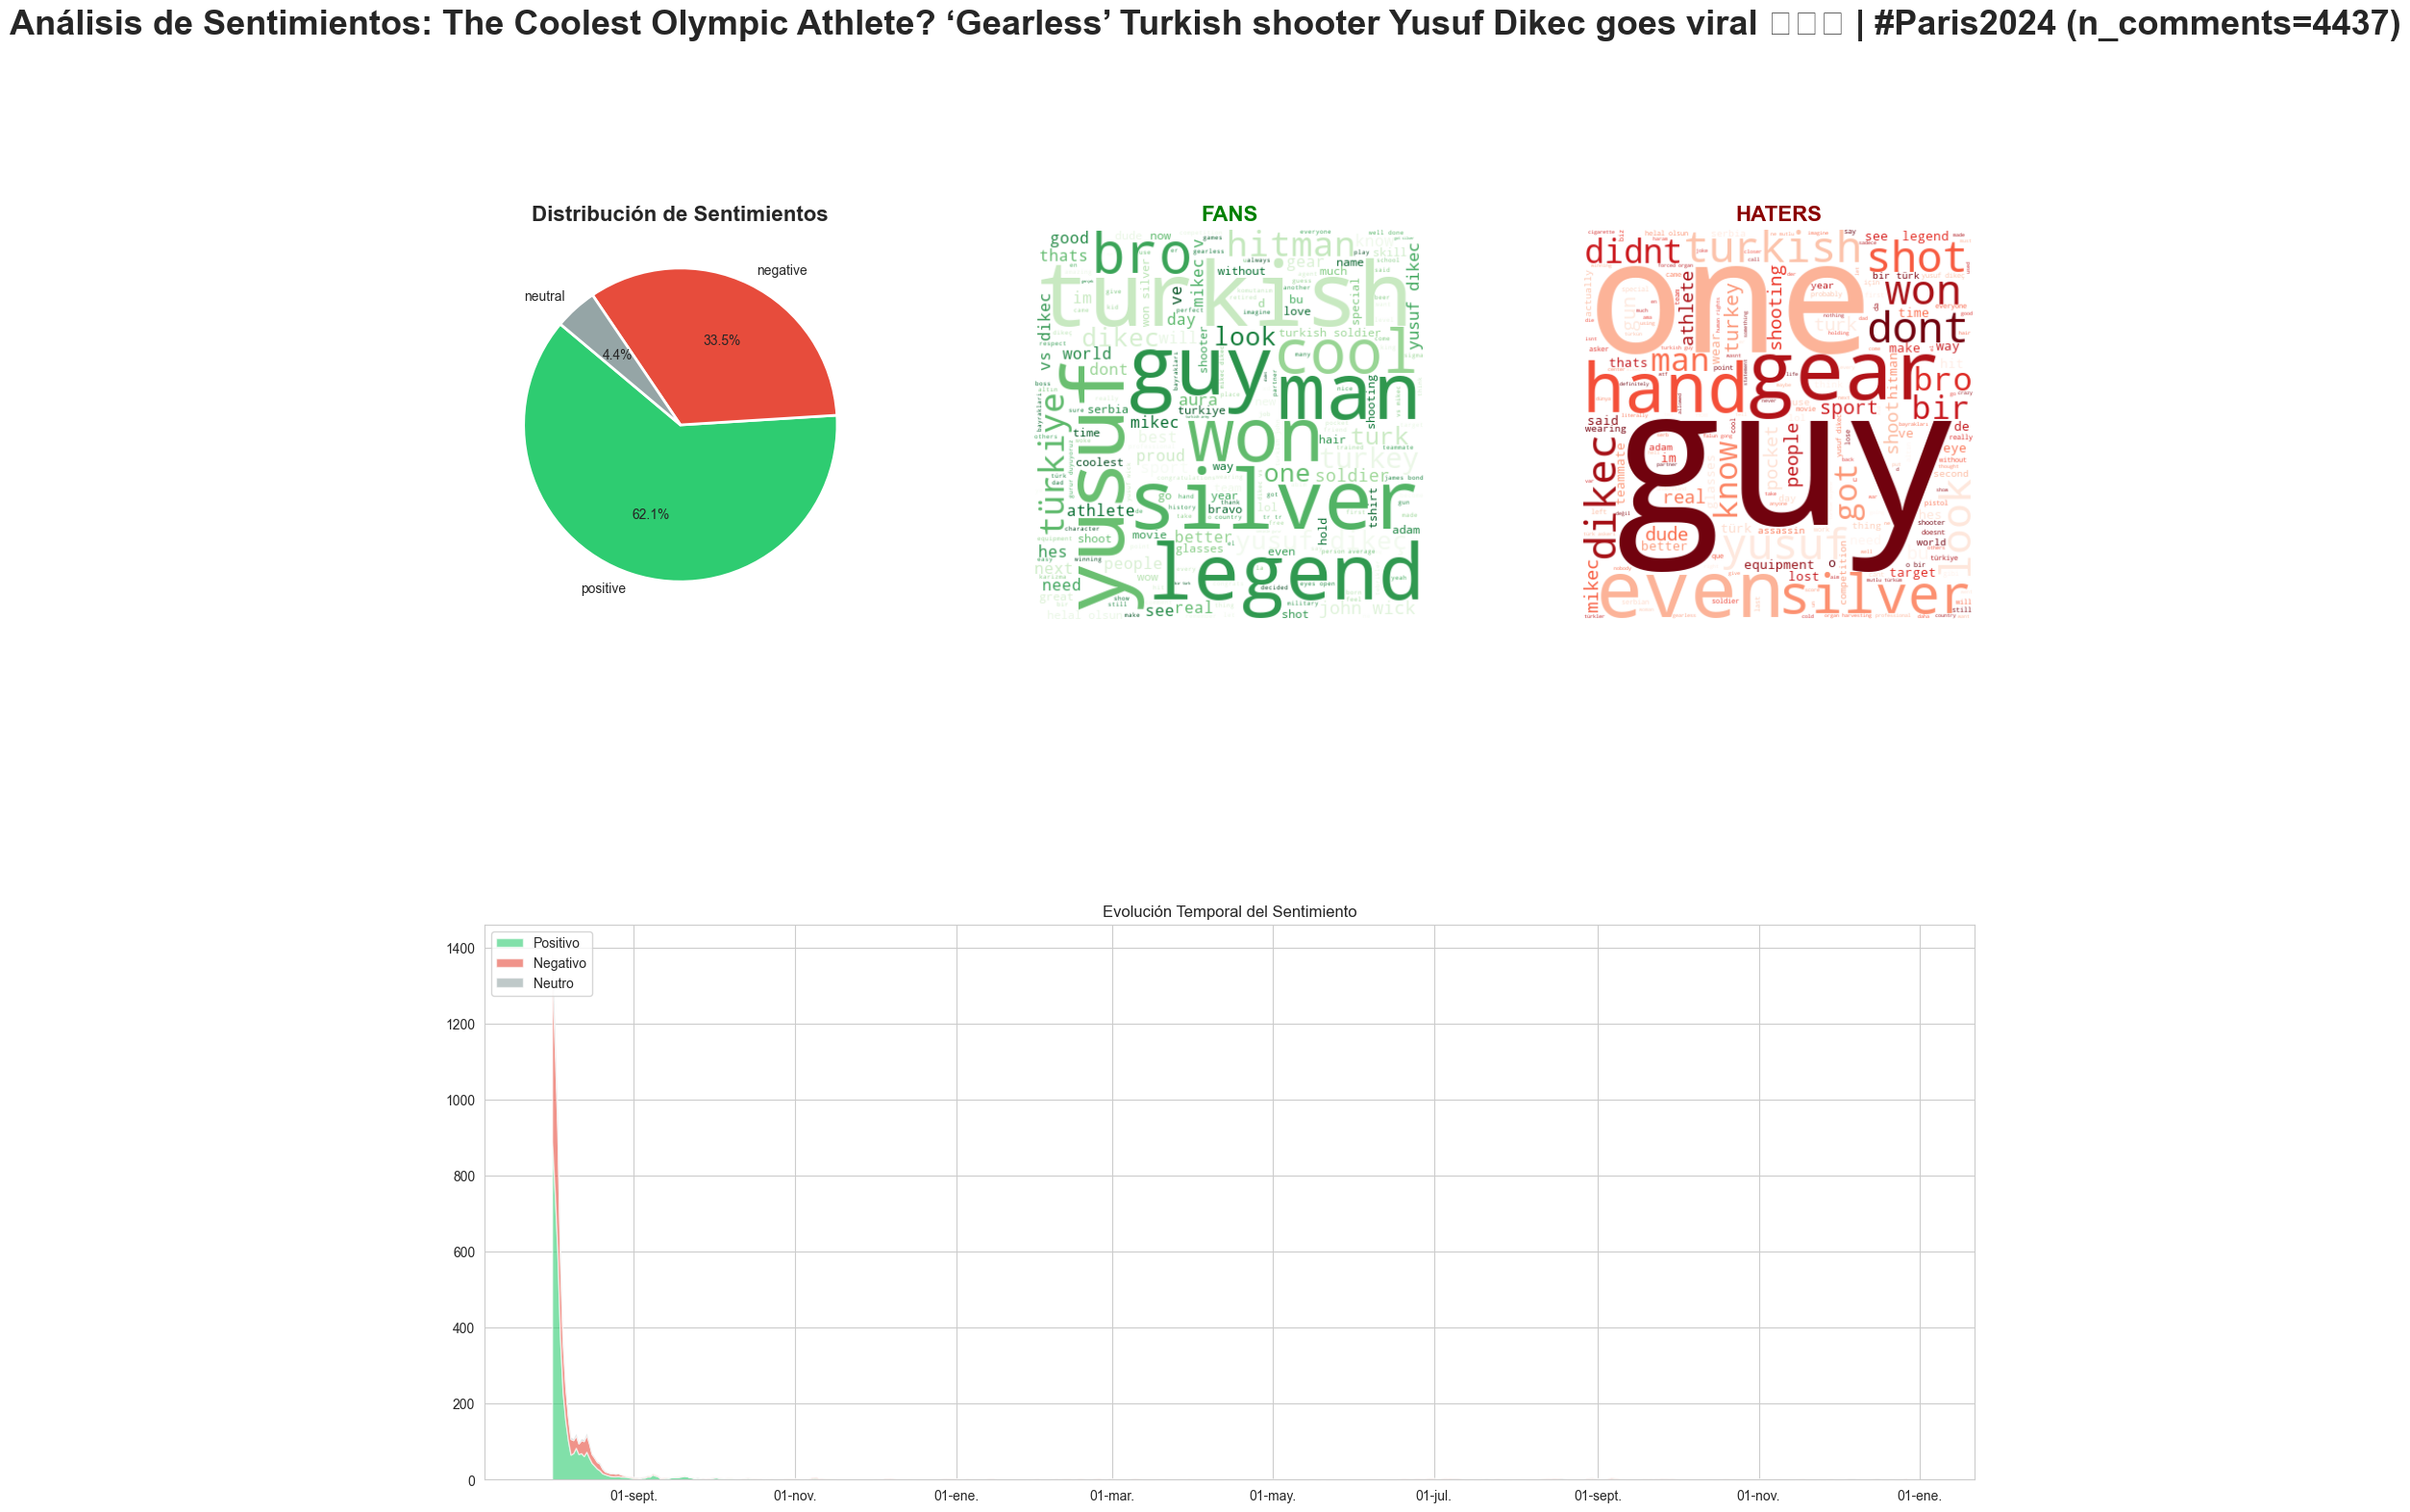

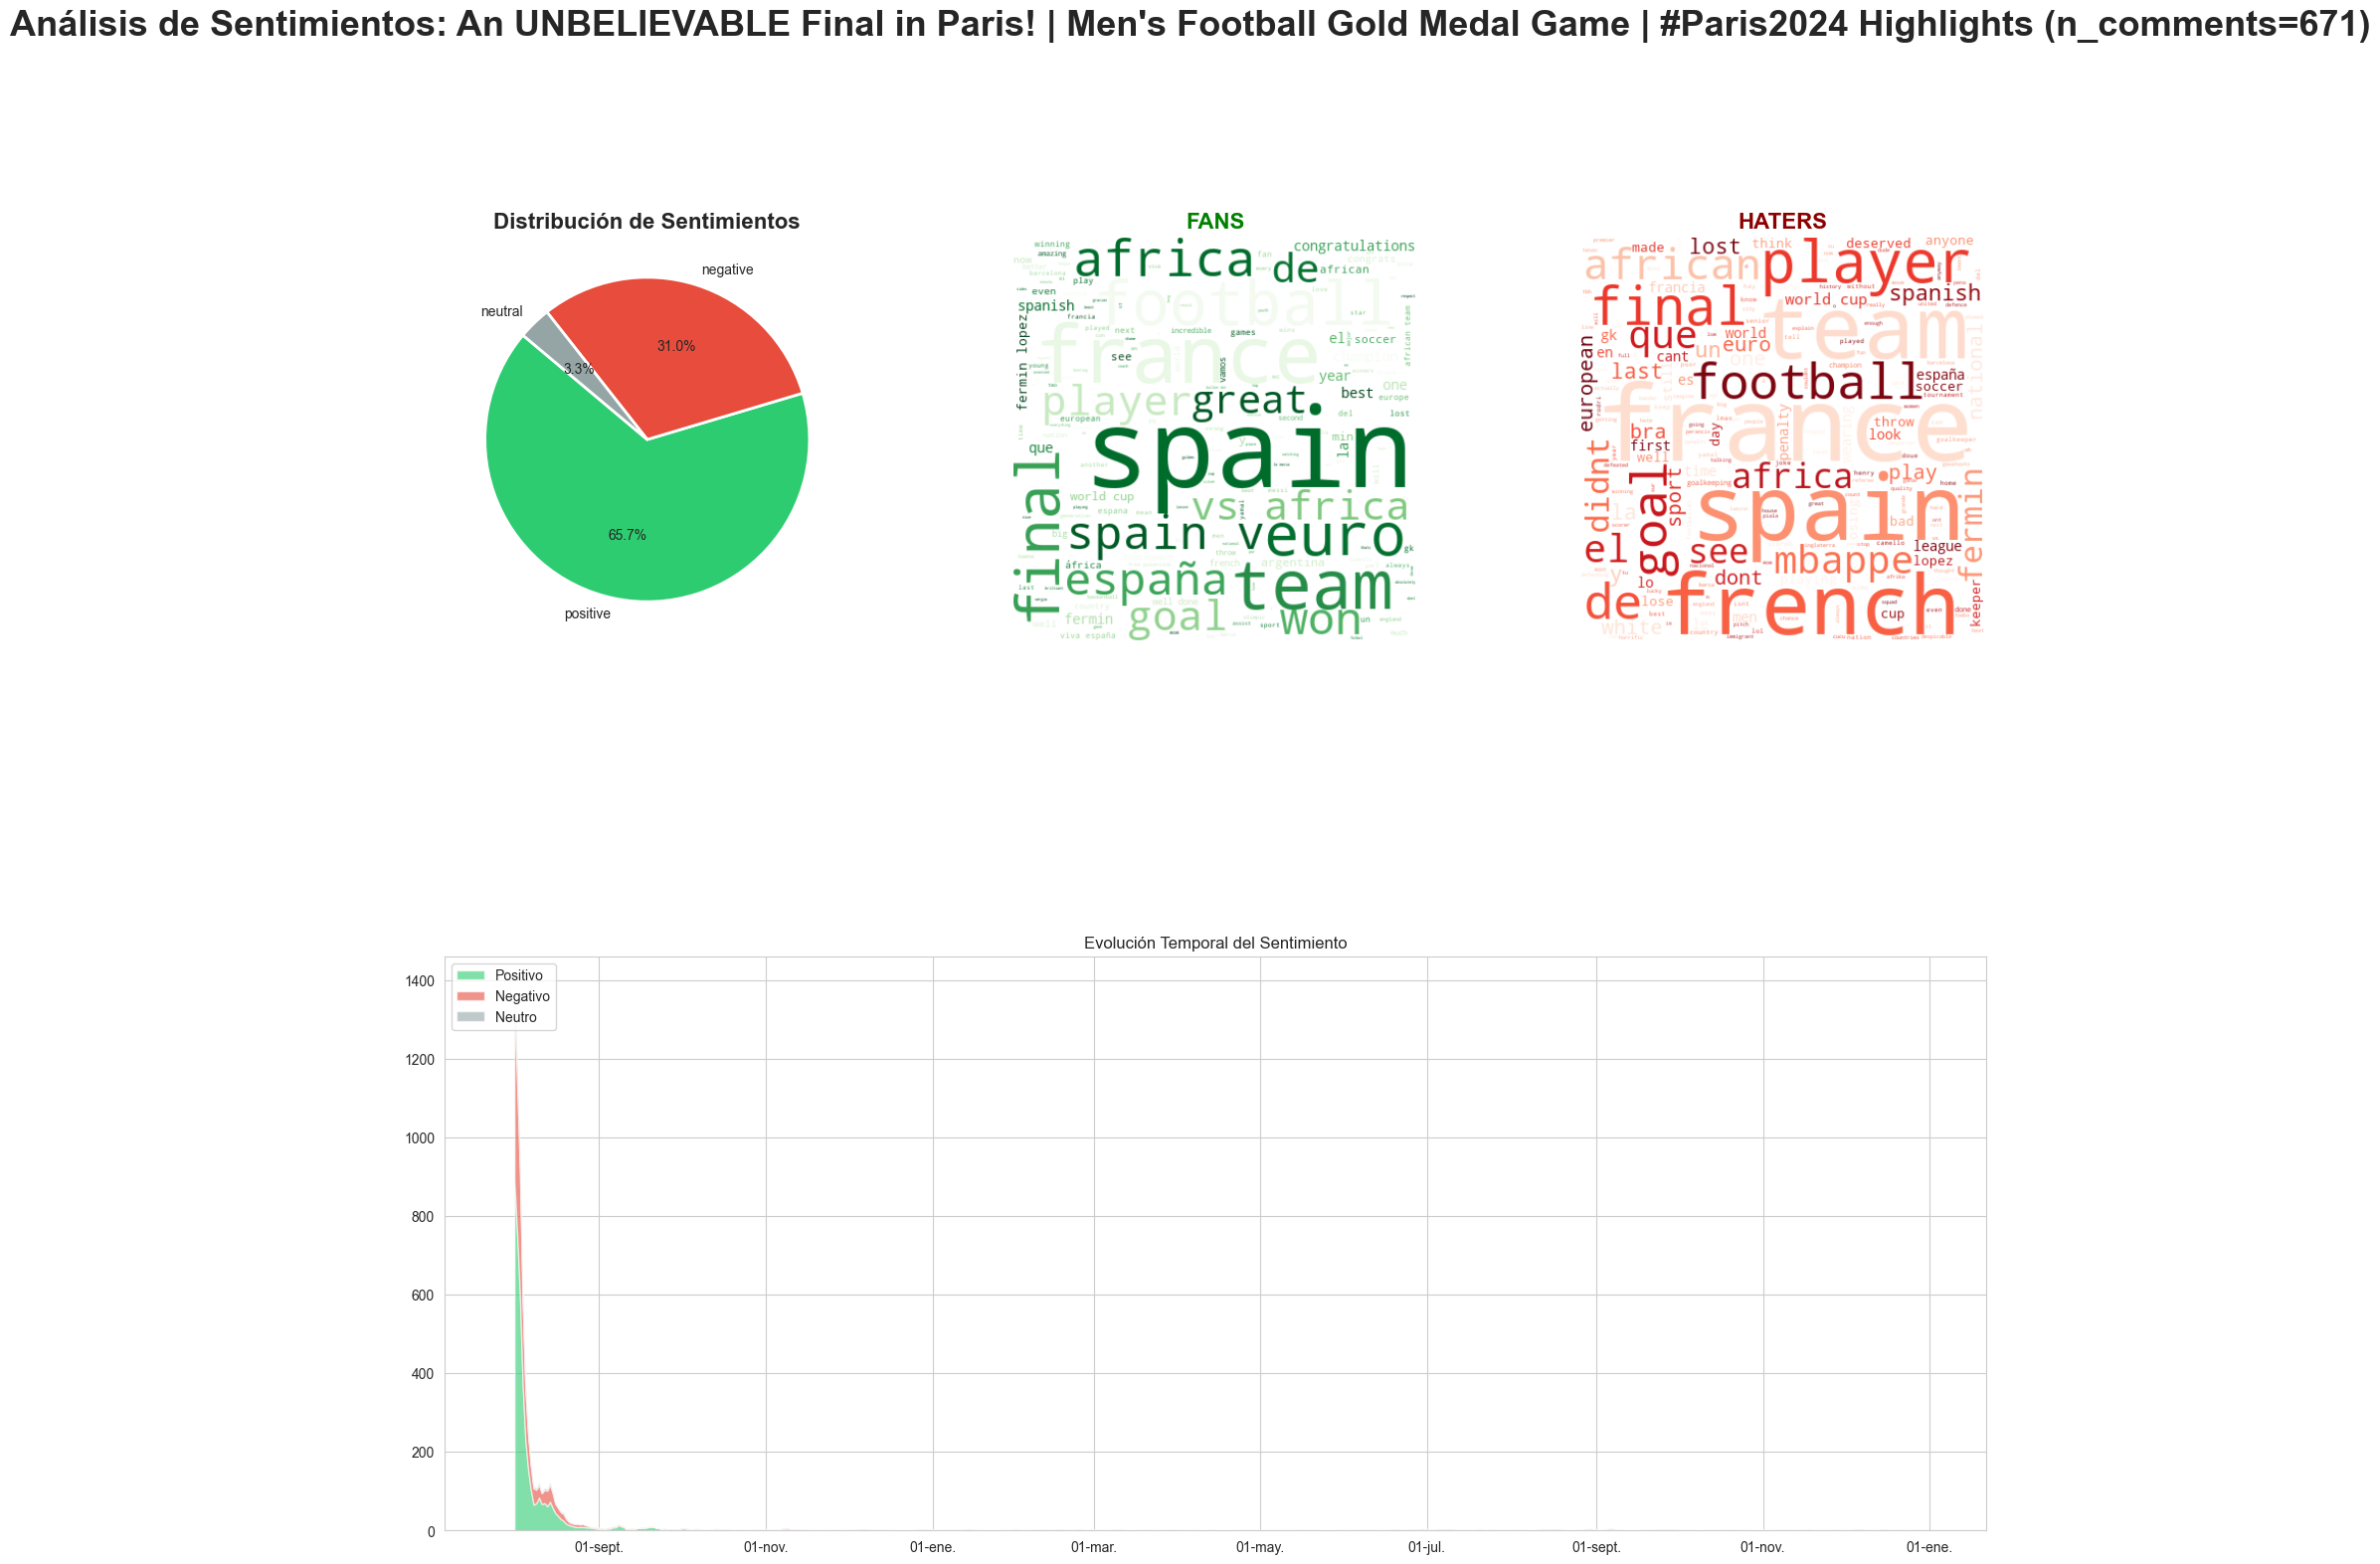

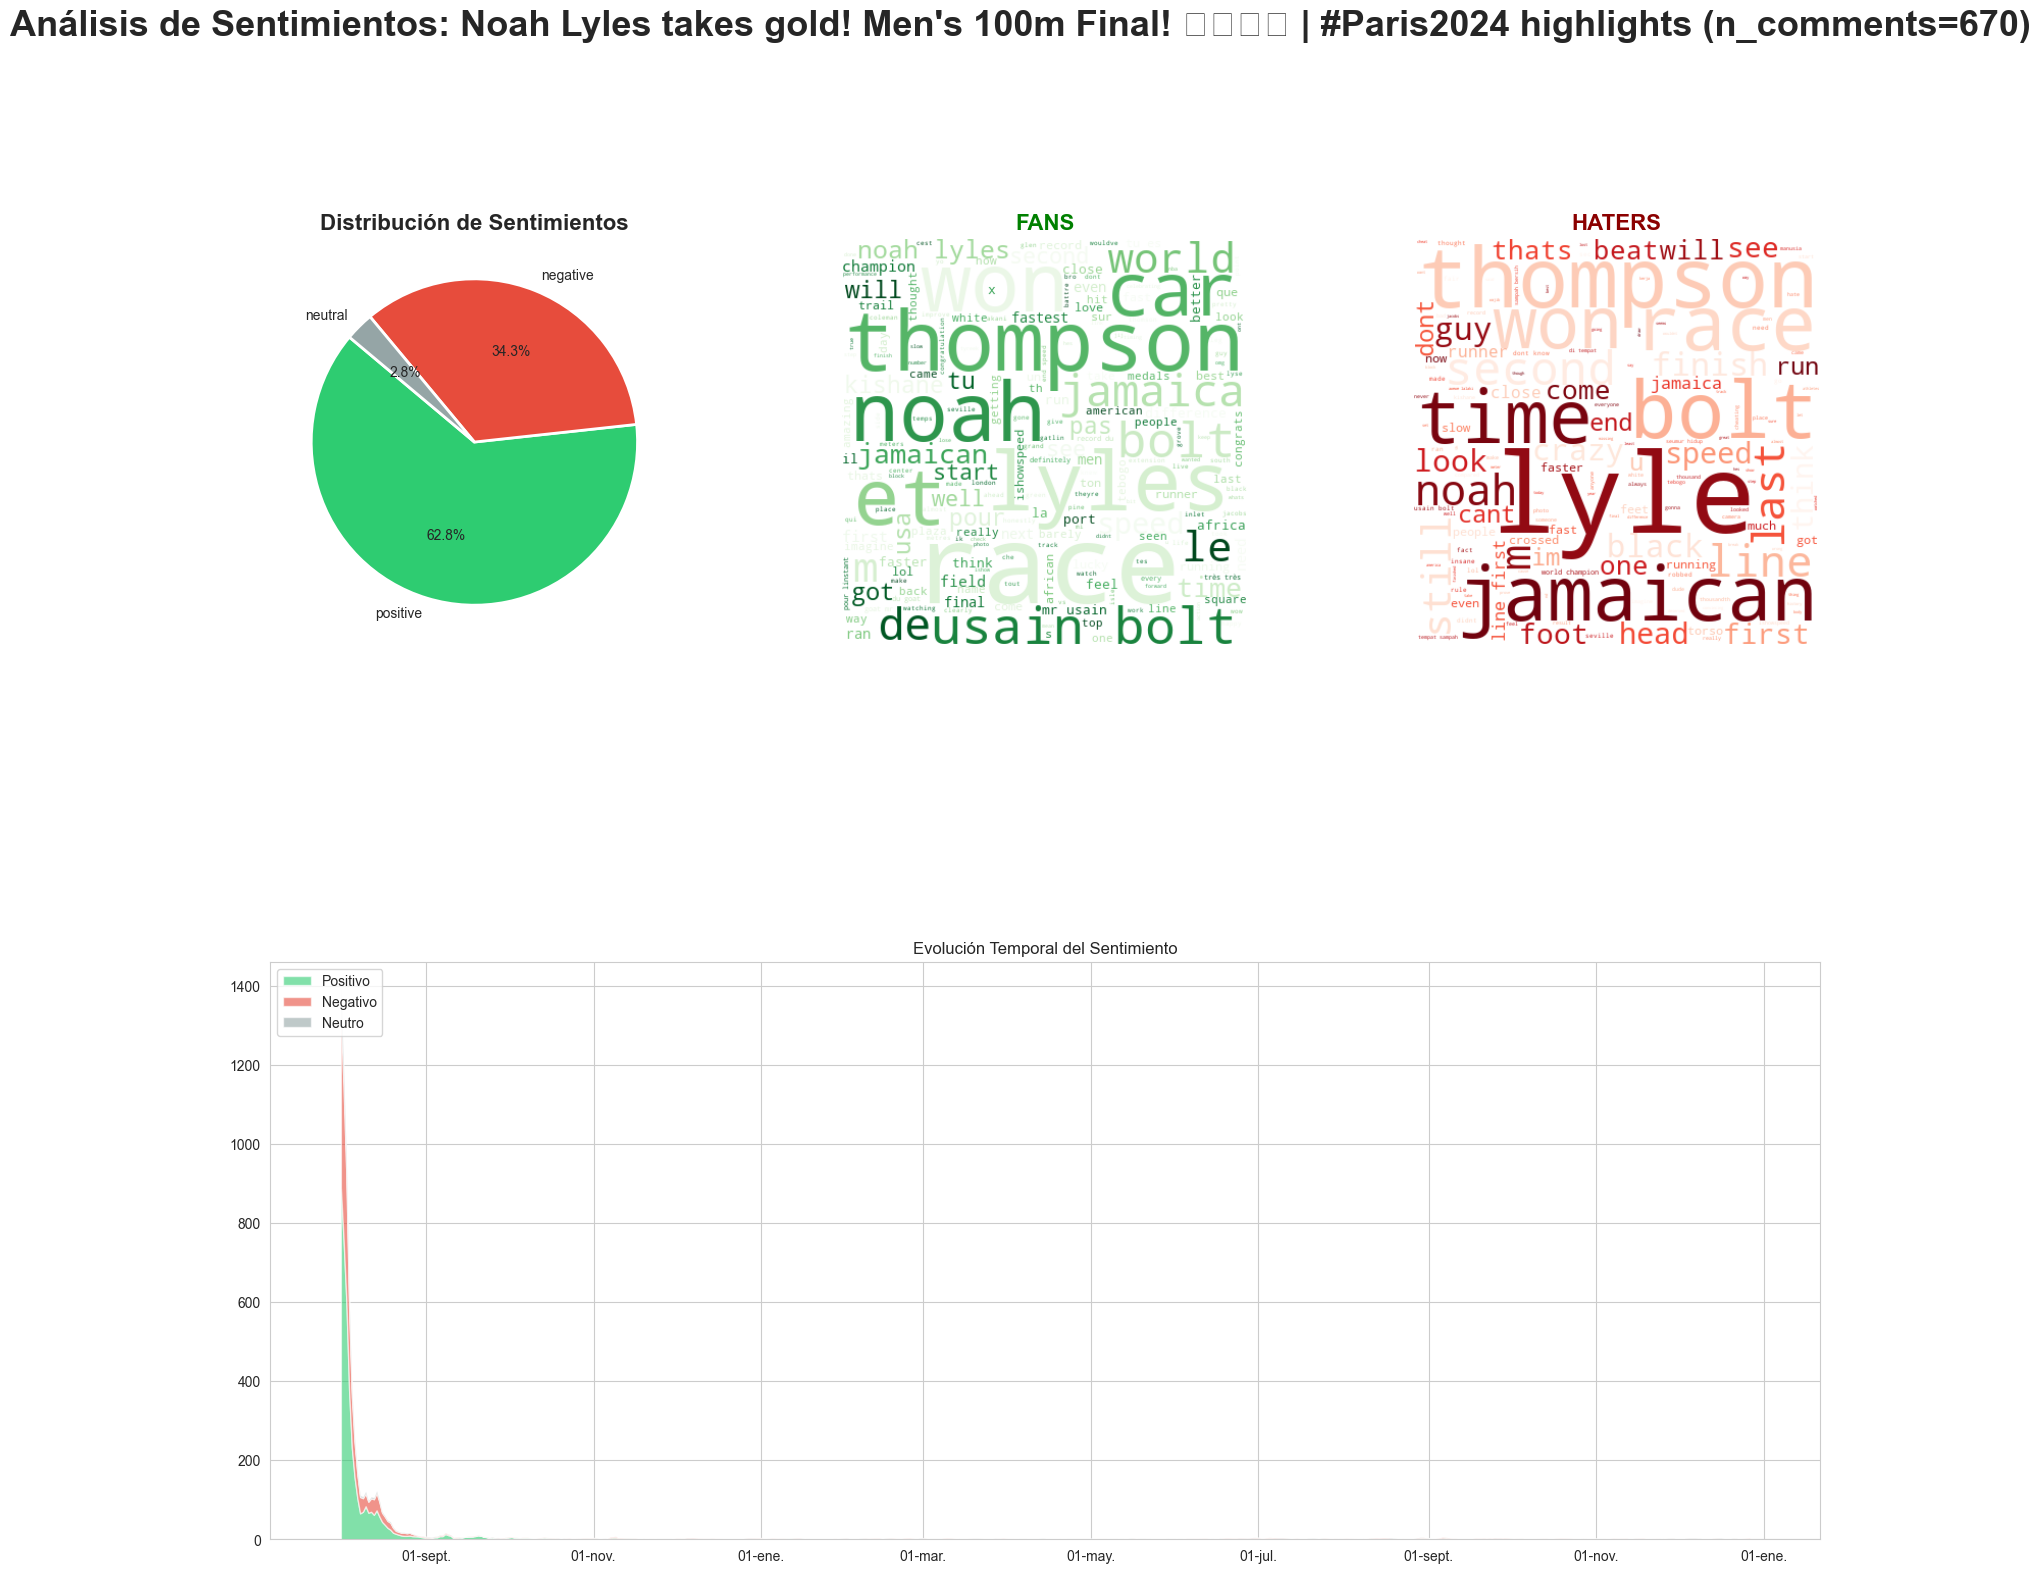

In [15]:
unique_videos = df_with_sentiments['video_label'].unique()
for video in unique_videos:
    df_video = df_with_sentiments[df_with_sentiments['video_label'] == video]

    total_comments = len(df_video)
    fig = plt.figure(figsize=(20, 18))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.4)
    fig.suptitle(f"Análisis de Sentimientos: {video} (n_comments={total_comments})", fontsize=26, fontweight='bold', y=0.96)

    # Distribución de Sentimientos por Video
    ax_1 = fig.add_subplot(gs[0, 0])
    conteo_video = df_video['sentiment_distilbert'].value_counts()
    ax_1.pie(conteo_video, labels=conteo_video.index, autopct='%1.1f%%', startangle=140,
            colors=[colores.get(x, '#333') for x in conteo_video.index], wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax_1.set_title('Distribución de Sentimientos', fontsize=16, fontweight='bold')

    # WordCloud Positiva por Video
    ac_wc_pos = fig.add_subplot(gs[0, 1])
    text_pos_video = " ".join(df_video[df_video['sentiment_distilbert'] == 'positive']['clean_text'])
    if len(text_pos_video) > 0:
        wc_pos_video = WordCloud(stopwords=stopwords_set, background_color="white", colormap="Greens", height=400, width=400).generate(text_pos_video)
        ac_wc_pos.imshow(wc_pos_video, interpolation='bilinear')
        ac_wc_pos.set_title('FANS', fontsize=16, fontweight='bold', color='green')
    ac_wc_pos.axis("off")

    # WordCloud Negativa por Video
    ac_wc_neg = fig.add_subplot(gs[0, 2])
    text_neg_video = " ".join(df_video[df_video['sentiment_distilbert'] == 'negative']['clean_text'])
    if len(text_neg_video) > 0:
        wc_neg_video = WordCloud(stopwords=stopwords_set, background_color="white", colormap="Reds", height=400, width=400).generate(text_neg_video)
        ac_wc_neg.imshow(wc_neg_video, interpolation='bilinear')
        ac_wc_neg.set_title('HATERS', fontsize=16, fontweight='bold', color='darkred')
    ac_wc_neg.axis("off")

    # Timeline por Video
    ac_timeline = fig.add_subplot(gs[1, :])
    timeline_video = df_video.groupby([pd.Grouper(key='published_at', freq='D'), 'sentiment_distilbert']).size().unstack(fill_value=0)
    timeline_video_smooth = timeline_video.rolling(window=2, min_periods=1).mean()
    if not timeline_smooth.empty:
        # Gráfico de Áreas Apiladas
        ac_timeline.stackplot(timeline_smooth.index,
                        timeline_smooth.get('positive', 0),
                        timeline_smooth.get('negative', 0),
                        timeline_smooth.get('neutral', 0),
                        labels=['Positivo', 'Negativo', 'Neutro'],
                        colors=[colores['positive'], colores['negative'], colores['neutral']], alpha=0.6)
        ac_timeline.set_title("Evolución Temporal del Sentimiento")
        ac_timeline.legend(loc='upper left')
        ac_timeline.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    else:
        ac_timeline.text(0.5, 0.5, "Datos temporales insuficientes", ha='center')

    plt.show()

## Conclusiones del Análisis Exploratorio de Datos (EDA) por video individual:

### Sydney McLaughlin - Oro 400m vallas femenino
Dato positivo: 61% | Dato negativo: 32.4%


Los datos muestran que 1 de cada 3 comentarios son negativos, lo cual es significativo en un evento tan celebrado. Sin embargo, la mayoría positiva indica un consenso general de admiración por su logro histórico. No es un vídeo unánime y para entenderlo podemos explicarlo con la nube de palabras.

**Fans**: Palabras como "amazing", "congratulations", "wow" reflejan un lenguaje de admiración y celebración, destacando la percepción de McLaughlin como una figura icónica en el atletismo.


**Haters**:Observamos palabras como "race", "bol", "femke", "world record" que podemos deducir que no es un odio personal hacia Sydney McLaughlin, sino una crítica hacia la competencia, el contexto de su victoria y de la rivalidad deportiva en general.
Puede ser que gran parte de los comentarios se refieren a Femke Bol, la atleta neerlandesa que compitió contra McLaughlin, y a la comparación de tiempos.

La polarización tiene una naturaleza competitiva más que personal, y el modelo detecta como negativo el conflicto entre fans de ambas atletas.

Evolución temporal:
Observamos un pico masivo y vertical al inicio del evento, seguido de una caída rápida en los comentarios positivos. Esto indica que la euforia inicial fue intensa pero efímera. Podemos entender esto como un fenómeno típico de eventos deportivos, donde la audiencia ve el vídeo, el récord mundial expresa una emoción inmediata, pero luego la atención se desvanece rápidamente.


### The Coolest Olympic Athlete? ‘Gearless’ Turkish shooter Yusuf Dikec goes viral
Dato positivo: 62.5% | Dato negativo: 33.4%


De la misma forma que el vídeo anterior, observamos que 1 de cada 3 comentarios son negativos, pero aquí la mayoría positiva indica un consenso general de admiración por su estilo único y viralidad, ¿por qué la gente odia a un tirador por su estilo sin equipo especial?
**Fans**: Tenemos palabras que no se van a "legend", "aura", "hitman", "cool", "soldier", de este tipo de palabras podemos deducir que la audiencia admira su estilo único y lo percibe como una figura carismática y casi heroica en el deporte, no se está celebrando la medalla de plata, sino que se está celebrando su estilo y su personalidad. El resultado deportivo es secundario frente a la personalidad de Yusuf Dikec.


**Haters**: Aquí tenemos palabras como "guy", "hand", "one, "shoot", "won", "gear" que claramente son palabras negativas, pero en este contexto la gente habla de su estilo sin equipo especial. El modelo **DistilBERT** está clasificando estas palabras como negativas en frases que contienen palabras asociadas al odio, crítica o violencia como puede ser "shoot", "gun" o "hitman". La mayoría de los comentarios negativos es ruido semántico generado por la ambigüedad de estas palabras en el contexto del tiro deportivo, y podemos concluir que es un falso negativo.

Respecto a la evolución temporal, observamos un pico inicial en los comentarios positivos durante el evento, seguido de una caída rápida. Esto indica que la viralidad del vídeo generó una emoción inmediata, pero la atención se disipó rápidamente después del evento.


### An UNBELIEVABLE Final in Paris! | Men's Football Gold Medal Game
Dato positivo: 64.1% | Dato negativo: 31.7%


Observamos el mismo efecto que en los 2 vídeos anteriores, 1 de cada 3 comentarios son negativos. El fútbol es un deporte con mucha pasión y rivalidad, y esto se refleja en la polarización de los comentarios. Además, la final entre España y Francia es un evento altamente competitivo y emocional, lo que puede generar opiniones divididas entre los aficionados de ambos equipos sumado a que la final tuvo lugar en París, Francia, lo que añade un elemento de rivalidad nacional con el país vencedor, España.

**Fans**: Palabras como "spain", "won", "football", "euro", "great", "team", "final". Aquí la palabras clave es "euro" que refleja la conexión entre la victoria olímpica y el éxito previo de España en la Eurocopa 2024. Esto sugiere que los aficionados están celebrando no solo la medalla de oro, sino también el dominio continuo de España en el fútbol europeo ya que también eliminaron a Francia en la Eurocopa 2024.


**Haters**: Aquí tenemos palabras como "team", "french", "african", "player", "deserved". La palabra "african" está vinculada a "french" y "team" donde se refleja una narrativa social y política en las redes y cuestionan la identidad nacional de los jugadores franceses, muchos de los cuales tienen orígenes africanos. Esto puede generar controversia y debates sobre la representación y la identidad en el deporte, lo que añade una capa adicional de complejidad a los comentarios negativos.
Otras palabras como "deserved" reflejan la percepción de injusticia o controversia sobre el resultado del partido, lo que puede generar críticas y debates entre los aficionados.

Respecto a la evolución temporal se observa el mismo patrón que en los vídeos anteriores.

### Noah Lyles takes gold! Men's 100m Final!
Dato positivo: 70.2% | Dato negativo: 28.3%


Observamos que en este vídeo la proporción de comentarios negativos es menor, 1 de cada 4 comentarios son negativos. Esto puede deberse a que Noah Lyles es un atleta muy popular y carismático, y su victoria en los 100m es vista como un logro impresionante. Además, el atletismo tiende a generar menos controversia que otros deportes como el fútbol, lo que puede explicar la menor polarización en los comentarios.

**Fans**: Palabras como "usain bolt", "jamaica", "race", "car", "champion". Los fans están comparando a Noah Lyles con Usain Bolt, el legendario velocista jamaicano, lo que indica un alto nivel de admiración y expectativa. La mención de "car" sugiere que los espectadores perciben la velocidad de Lyles como algo extraordinario, casi sobrehumano, similar a la velocidad de un automóvil. Esto refleja la percepción de Lyles como un campeón excepcional en el atletismo.


**Haters**: Palabras como "line", "photo", "Thompson", "kishane", "foot", "finish". La negatividad es este caso es objetiva y técnica debido a que la carrera tuvo un final muy ajustado y hubo controversia sobre la foto finish para determinar el ganador. Los comentarios negativos probablemente se centran en disputas sobre la precisión de la decisión. El modelo clasifica como negativo el debate técnico sobre la validez del resultado, más que un ataque personal hacia Lyles.

A diferencia de los otros vídeos, la línea temporal muestra rebotes más suaves a finales de agosto, septiembre y a lo largo de octubre.





# Fase 4: Construcción de Modelos RNN y Seq2Seq

Ahora que tienes un conjunto de datos clasificado y limpio, procederás a construir dos tipos de modelos de redes neuronales: uno utilizando una RNN Simple y otro basado en la arquitectura Seq2Seq (Encoder-Decoder). Estas redes son especialmente útiles en tareas de procesamiento de secuencias como el análisis de sentimientos.

Objetivo: Aprender a implementar y entrenar redes neuronales especializadas en el procesamiento de secuencias de texto, entendiendo las diferencias entre las arquitecturas.

Para implementar **los modelos de redes redes neuronales** tenemos que aplicar varias técnicas de preprocesamiento y preparación de datos:


1. **Vectorización**: Las redes neuronales no son capaces de leer texto directamente, por lo que necesitamos convertir las palabras en números. Utilizaremos la tokenización para transformar cada palabra en un entero único, creando así secuencias numéricas que representen los comentarios.


2. **Padding**:Cada comentarios en YouTube tiene una longitud diferente (número de palabras). Las redes neuronales requieren entradas de longitud fija, por lo que aplicaremos padding para rellenar las secuencias más cortas con ceros hasta alcanzar la longitud máxima definida. Esto lo hemos observado en el boxplot de longitud de comentarios, donde vemos que los comentarios positivos suelen ser más cortos (mediana 4 palabras) que los negativos (mediana 10 palabras). Por lo tanto, el padding nos ayudará a estandarizar la longitud de las secuencias para que el modelo pueda procesarlas de manera uniforme.


3. **Gestión del Desbalance de Clases**: Nuestro dataset presenta un desbalance significativo entre las clases de sentimientos, con una mayoría de comentarios positivos (62%) y una minoría de comentarios neutrales (4.2%). Para evitar que el modelo aprenda a predecir siempre la clase mayoritaria, implementaremos pesos de clase (class weights) durante el entrenamiento. Si no aplicamos esto, el modelo tenderá a predecir siempre "Positivo" para maximizar la precisión sin aprender realmente a distinguir entre las clases.

**Arquitectura A: RNN Simple**
Este modelo sirve es rápido de entrenar y nos servirá para comparar resultados. Sin embargo, las RNN simples tienen limitaciones en la retención de información a largo plazo debido al problema del desvanecimiento del gradiente. Esto significa que pueden tener dificultades para capturar contextos complejos en los comentarios, como ironías o negaciones. Por lo tanto, este modelo servirá como una línea base académica para comparar con modelos más avanzados.


**Arquitectura B: LSTM (Long Short-Term Memory)**
Este modelo es el estándar industrial para tareas de procesamiento de secuencias. Las LSTM utilizan celdas de memoria que les permiten retener información durante períodos más largos, lo que es crucial para entender contextos complejos en los comentarios, como ironías o negaciones. Esta arquitectura nos permitirá capturar mejor las sutilezas del lenguaje y mejorar la precisión en la clasificación de sentimientos.


Al principio del notebook hemos definido los hiperparámetros principales del modelo:
- **MAX_VOCAB_SIZE = 5000** El vocabulario máximo.
  - Consiste en quedarnos con las 5000 palabras más frecuentes en el dataset para reducir la dimensionalidad y evitar el ruido de palabras raras o irrelevantes. El resto de palabras se consideran como "OOV" (Out Of Vocabulary) y se asignan a un token especial.
  - Si elegimos un valor demasiado bajo, corremos el riesgo de perder palabras importantes que podrían ser clave para entender el sentimiento. Por otro lado, un valor demasiado alto puede introducir ruido y aumentar la complejidad del modelo innecesariamente.
- **MAX_SEQUENCE_LEN = 100** Es la ventana de atención.
  - Fuerza que todos los comentarios tengan una longitud fija de 100 palabras-tokens (con padding o truncamiento). Esto ayuda a estandarizar las entradas para la red neuronal y permite que el modelo se enfoque en las partes más relevantes del comentario. Si un comentario tiene más de 100 palabras, se corta y perdemos la información adicional que podría ser útil. Sin embargo, dado que la mayoría de los comentarios son relativamente cortos (mediana 4-10 palabras), este valor es adecuado para capturar la mayoría del contenido relevante sin introducir demasiado padding. En el caso contrario de comentarios más cortos, se añaden ceros al final para completar la longitud.
  - Al aumentar el valor de MAX_SEQUENCE_LEN, podríamos capturar más contexto en comentarios largos, pero esto también incrementaría el tiempo de entrenamiento y la complejidad del modelo, además de introducir más padding en comentarios cortos, lo que podría afectar negativamente el rendimiento en este caso de dataset.
  - **Desvanecimiento de gradiente**: en una RNN simple, si usamos este valor muy alto, la red olvida la primera parte del comentario al llegar al final, perdiendo contexto importante. Lo vamos a mantener en 100 para evitar este problema y la LSTM podrá retener mejor la información relevante. En el análisis exploratorio vimos que la mayoría de los comentarios son cortos, en función del problema y el dataset, este valor puede ajustarse.
- **EMBEDDING_DIM = 100** Resolución semántica.
  - Define cuántos números usará el modelo para representar cada palabra en el espacio vectorial. Un valor de 100 significa que cada palabra se representará como un vector de 100 dimensiones.
  - Esto se puede entender como la "resolución" con la que el modelo percibe las palabras. Un valor más alto permite capturar matices semánticos más finos, pero también aumenta la complejidad del modelo y el tiempo de entrenamiento.
  - Ejemplo: Con una resolución baja (por ejemplo, 10-20) los modelos no son capaces de distinguir bien entre palabras con significados similares, como "bueno" y "excelente". Con una resolución más alta (100-300), el modelo puede captar mejor las diferencias sutiles en el significado y uso de las palabras, lo que es crucial para tareas de análisis de sentimientos donde los matices son importantes.

In [16]:
X_raw = df_with_sentiments['clean_text'].values
y_raw = df_with_sentiments['sentiment_distilbert'].values

label_encoder = LabelEncoder()
# Codificar etiquetas de texto a números
y_encoded = label_encoder.fit_transform(y_raw)
y_categorical = to_categorical(y_encoded)

# Hacemos el split sobre los textos crudos y las etiquetas codificadas
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_raw, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded # Mantenemos proporción de clases
)

print(f"Datos divididos: {len(X_train_text)} Train vs {len(X_test_text)} Test")

# Tokenización y Secuenciación en los datos de train
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text) # Aprende vocabulario SOLO del Train

# Transformación de Secuencias, convertimos texto a números usando lo aprendido
train_sequences = tokenizer.texts_to_sequences(X_train_text)
test_sequences = tokenizer.texts_to_sequences(X_test_text) # Si hay palabras nuevas, serán <OOV>

# Padding (Estandarización)
X_train = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LEN, padding='post', truncating='post')
X_test = pad_sequences(test_sequences, maxlen=MAX_SEQUENCE_LEN, padding='post', truncating='post')

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test: {X_test.shape}")


# Recálculo de Pesos de Clase (Sobre y_train real)
y_integers_train = np.argmax(y_train, axis=1)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_integers_train),
    y=y_integers_train
)
class_weight_dict = dict(enumerate(class_weights))

class_weight_dict = dict(enumerate(class_weights))

print("Pesos de Clase Actualizados:")
for i, weight in class_weight_dict.items():
    print(f"Clase '{label_encoder.classes_[i]}': Peso {weight:.2f}")

Datos divididos: 4879 Train vs 1220 Test
Shape X_train: (4879, 100)
Shape X_test: (1220, 100)
Pesos de Clase Actualizados:
Clase 'negative': Peso 1.00
Clase 'neutral': Peso 7.89
Clase 'positive': Peso 0.53


### Interpretación de los pesos de clase
La fórmula balanced intenta que todas las clases tengan la misma importancia (peso) para el modelo, con el objetivo de mitigar el sesgo hacia las clases mayoritarias.


Clase negativa: **Peso=1.00** signigica que está equilibrada, aproximadamente el 33,4% de los datos son negativos (tenemos 3 clases)


Clase neutral: **Peso=7.89** es mucho mayor a 1.00 esto significa que es la clase minoritaria y es lo que hemos visto en el análisis exploratorio de datos (EDA) donde la clase neutral solo representa el 4.2% del total de comentarios. Al asignar un peso más alto a esta clase, el modelo se ve incentivado a prestar más atención a los ejemplos neutrales durante el entrenamiento, ayudando a mitigar el sesgo hacia las clases mayoritarias (positivo y negativo).


Clase positiva: **Peso=0.53** al ser menor a 1.00 indica que es la clase mayoritaria y por lo tanto el modelo le asigna menos importancia relativa durante el entrenamiento, el 64.2% de los datos son positivos. (No se le da tanta importancia a la clase mayoritaria para evitar que el modelo se sesgue hacia ella).

### Construcción de los modelos de RNN y LSTM

**RNN Simple**:
- Capa de Embedding: Convierte las secuencias de enteros(tokens) en vectores densos de dimensión EMBEDDING_DIM, transformando las palabras en representaciones numéricas que capturan relaciones semánticas.
- Capa SimpleRNN: Procesa las secuencias temporal utilizando 64 neuronas, al usar return_sequences=False, solo devuelve la salida final, resumiendo la información de toda la secuencia en un solo vector.
- Capa Densa 1: Procesa las salidas de la RNN con 32 unidades y activación ReLU para aprender representaciones intermedias más complejas.
- Capa Dropout: Se añade una capa de Dropout con tasa 0.5 para reducir el sobreajuste, desactivando aleatoriamente el 50% de las neuronas durante el entrenamiento, de esta forma el modelo generaliza mejor y no se aprende de memoria los datos de entrenamiento.
- Capa Densa 2: Capa intermedia con 32 unidades y activación ReLU que refina las características despues del Dropout y antes de la clasificación final.
- Capa de salida Densa: Clasifica la salida en 3 clases utilizando softmax (obteniendo probabilidades para cada clase).
- Compilación: Utiliza el optimizador Adam y la función de pérdida de entropía cruzada categórica, adecuada para problemas de clasificación multiclase.

**LSTM**:
- Capa de Embedding: Similar a la RNN, convierte las secuencias en vectores densos (EMBEDDING_DIM) de forma que aprende representaciones semánticas.
- Capa Bidirectional LSTM:Envuelve la capa LSTM de 64 unidades con una configuracion bidireccional, permitiendo que el modelo pueda procesar el texto de izquierda a derecha y de derecha a izquierda, capturando contexto completo. Esto permite retener información a largo plazo y manejar dependencias complejas en los comentarios como las ironías.
- Capa Densa: Añadimos otra capa densa intermedia con 64 unidades con activación ReLU para aprender representaciones más complejas antes de la clasificación final.
- Capa Dropout: Se añade una capa de Dropout con tasa 0.5 para reducir el sobreajuste, desactivando aleatoriamente el 50% de las neuronas durante el entrenamiento, de esta forma el modelo generaliza mejor y no se aprende de memoria los datos de entrenamiento.
- Capa de Salida Densa: Clasifica la salida en 3 clases utilizando softmax (obteniendo probabilidades para cada clase).
- Compilación: Similar a la RNN, utiliza Adam y entropía cruzada categórica.

**Seq2Seq (Encoder-Decoder)**: Esta arquitectura separa la compresión de la información (encoder-lectura) de la generación de la salida-predicción (decoder-escritura), lo que permite manejar secuencias de entrada y salida de diferentes longitudes. En este caso, el encoder procesa el comentario y el decoder genera la etiqueta de sentimiento correspondiente.
- Encoder (LSTM): Encargado de leer la secuencia de entrada (comentario) y comprimir la información en un "Vector de Contexto" (Context Vector), descarta la secuencia temporal y se queda sólo con el significado semántico puro del comentario.
- RepeatVector: Duplicamos el Vector de Contexto para que el decoder pueda tener acceso a toda la información comprimida durante cada paso de tiempo de la salida.
- Decoder (LSTM): Recoge el vector de contexto repetido y extrae las características de alto nivel aisladas por el encoder para generar la secuencia de salida (etiqueta de sentimiento).
- Clasificador: Capas densas finales con Dropout para clasificar la salida en 3 clases utilizando softmax.
- Compilación: Similar a los otros modelos, utiliza Adam y entropía cruzada categórica.

In [17]:


def build_simple_rnn():
    model = Sequential(name="Simple_RNN")
    model.add(Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LEN))
    model.add(SimpleRNN(64, return_sequences=False))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(3, activation='softmax'))  #3 neuronas de salida para 3 clases
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_lstm():
    inputs = Input(shape=(MAX_SEQUENCE_LEN,))
    # Procesa el texto y extrae el contexto
    x = Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM)(inputs)
    # Usamos Bidirectional para que lea de izq->der y der->izq (Mejor comprensión)
    x =Bidirectional(LSTM(64, return_sequences=False))(x)
    # Toma el vector de contexto y decide
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(3, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs, name="Bidirectional_LSTM")
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_seq2seq():
    inputs = Input(shape=(MAX_SEQUENCE_LEN,))
    # Encoder (transformación de indices a vectores)
    embedding = Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM)(inputs)
    # LSTM Encoder (procesa la entrada y genera el "ConextVector" return_sequences=False)
    encoder_output = LSTM(64, return_sequences=False, name='Encoder_LSTM_seq2seq')(embedding)
    # Puente (RepeatVector para preparar la entrada del decoder)
    # Repite el vector de contexto para simular la entrada del Decored (es una técnica común para conecar encoder y decoder)
    repeated= RepeatVector(1)(encoder_output)
    # Decoder LSTM (procesa el vector repetido para refinar la predicción)
    decoder_output = LSTM(64, return_sequences=False, name='Decoder_LSTM_seq2seq')(repeated)
    # Clasificador
    x = Dropout(0.5)(decoder_output)
    x = Dense(32, activation='relu')(x)
    outputs = Dense(3, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=outputs, name='Seq2seq')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model




In [18]:
model_rnn_simple = build_simple_rnn()
model_lstm = build_lstm()
model_seq2seq = build_seq2seq()

model_rnn_simple.summary()
model_lstm.summary()
model_seq2seq.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

...

Model: "Seq2seq"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 100, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_LSTM_seq2seq (LSTM)     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_LSTM_seq2seq (LSTM)     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 577,443 (2.20 MB)

 Trainable params: 577,443 (2.20 MB)

 Non-trainable params: 0 (0.00 B)

# Fase 5: Entrenamiento e Hiperparametrización de los Modelos


Con las arquitecturas de RNN y Seq2Seq construidas, el siguiente paso es entrenar los modelos y ajustar los hiperparámetros como el número de épocas, el tamaño del batch y el número de unidades en las capas. El objetivo aquí es mejorar el rendimiento de cada modelo y explorar cómo las diferentes configuraciones afectan su precisión.



Objetivo: Optimizar el rendimiento de los modelos y experimentar con diferentes configuraciones de entrenamiento para obtener resultados más precisos.


Para realizar el entrenamiento de los modelos creados hacemos uso de la técnica Early Stopping (Detención Temprana). Esta técnica nos permite monitorear el rendimiento del modelo en un conjunto de validación durante el entrenamiento y detener el proceso si no se observa una mejora significativa después de un número determinado de épocas (paciencia). Esto es crucial para evitar el sobreajuste, donde el modelo aprende demasiado bien los datos de entrenamiento pero falla en generalizar a datos nuevos, al realizar esto es una forma de prevenir el **overfitting (sobreajuste)** y asegurar que el modelo mantenga un buen rendimiento en datos no vistos.

Hemos configurado los siguientes hiperparámetros para el entrenamiento de los modelos:

- **Batch Size = 32**: Este valor determina cuántos ejemplos de entrenamiento se procesan antes de actualizar los pesos del modelo. Un tamaño de batch de 32 ofrece un buen equilibrio entre la estabilidad del gradiente y la eficiencia computacional, ya que permite que el modelo aprenda de múltiples ejemplos a la vez, lo que puede mejorar la convergencia y reducir el ruido en las actualizaciones de los pesos.


- **Epochs = 30**: Este es el número máximo de veces que el modelo verá todo el conjunto de datos de entrenamiento. Hemos establecido un límite de 30 épocas para evitar un entrenamiento excesivo, pero con la técnica de Early Stopping, el entrenamiento puede detenerse antes si no se observa una mejora en el rendimiento del modelo en el conjunto de validación.


- **Validation Split = 0.1**: Hemos reservado el 10% de los datos de entrenamiento para la validación en tiempo real. Esto nos permite evaluar el rendimiento del modelo en datos no vistos durante el entrenamiento y ajustar los hiperparámetros en consecuencia.


- **Class Weights**: Dado el desbalance en las clases de sentimientos (positivo, negativo, neutral) que hemos visto en el EDA, hemos aplicado pesos de clase para asegurar que el modelo preste la debida atención a todas las clases durante el entrenamiento. Esto ayuda a mitigar el sesgo hacia la clase mayoritaria y mejora la capacidad del modelo para clasificar correctamente las clases minoritarias.


- **Early Stopping**: Hemos configurado la paciencia en 3 épocas, lo que significa que si el rendimiento del modelo en el conjunto de validación no mejora durante 3 épocas consecutivas, el entrenamiento se detendrá automáticamente. Esto ayuda a prevenir el sobreajuste y asegura que el modelo mantenga un buen rendimiento en datos no vistos.

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print("Entrenamiento del Modelo Simple RNN con Early Stopping y Pesos de Clase...")
history_earlystopping_rnn = model_rnn_simple.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

print("Entrenamiento del Modelo LSTM con Early Stopping y Pesos de Clase...")
history_earlystopping_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

print("Entrenamiento del Modelo Seq2Seq con Early Stopping y Pesos de Clase...")
history_earlystopping_seq2seq = model_seq2seq.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)



Entrenamiento del Modelo Simple RNN con Early Stopping y Pesos de Clase...
Epoch 1/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4671 - loss: 1.0839 - val_accuracy: 0.5943 - val_loss: 1.0809
Epoch 2/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5044 - loss: 1.0826 - val_accuracy: 0.3463 - val_loss: 1.0905
Epoch 3/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4926 - loss: 1.0826 - val_accuracy: 0.3463 - val_loss: 1.0926
Epoch 4/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4915 - loss: 1.0826 - val_accuracy: 0.5943 - val_loss: 1.0823
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Entrenanmiento del Modelo LSTM con Early Stopping y Pesos de Clase...
Epoch 1/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.8766 - loss: 0.2958 - val_accuracy: 0.7070 - val_loss: 0.7956
Epoch 2/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy: 0.8984 - loss: 0.2203 - val_accuracy: 0.7275 - val_loss: 0.800

In [23]:
y_integers_test = np.argmax(y_test, axis=1)
unique, counts = np.unique(y_integers_test, return_counts=True)
print("Distribución de Clases en el Set de Test:")
for label, count in zip(unique, counts):
    print(f"Clase '{label_encoder.classes_[label]}': {count} comentarios, {count/len(y_test)*100:.2f}%")

Distribución de Clases en el Set de Test:
Clase 'negative': 408 comentarios, 33.44%
Clase 'neutral': 51 comentarios, 4.18%
Clase 'positive': 761 comentarios, 62.38%


Explicación de los resultados obtenidos durante el entrenamiento:

**RNN**:


Observamos como en la primera época de entrenamiento obtenemos un accuracy del 59,43% en validación, pero al seguir entrenando el modelo no es capaz de mejorar su precisión en el conjunto de validación ya que el rendimiento cae a un 34,63% (nivel de azar con 3 clases), en la época 4 el modelo vuelve a recuperar el 59% pero debido al uso de Early Stopping restaura los pesos de la época 1, que fue donde se obtuvo el mejor rendimiento en validación.

Es un buen ejemplo del Desvanecimiento del Gradiente en RNNs Simples, donde la red olvida la información relevante de los comentarios a medida que procesa secuencias largas, lo que limita su capacidad para capturar contextos complejos necesarios para el análisis de sentimientos. Al intentar procesar 100 tokens, la RNN simple no es capaz de conectar el final de la frase con el principio, perdiendo así información crucial.

**LSTM**:

En este modelo podemos ver una clara mejora respecto a la RNN Simple. Desde la primera época, el modelo alcanza un accuracy del 70,70% y con una pérdida de 0.7956. Detectamos un overfitting temprano, el accuracy de entrenamiento llega al 92,42% en la época 3, pero la pérdida en validación (val_loss) empeora  progresivamente desde la época 2 (0.8001-0.8767-0.8640) lo que indica que el modelo comienza a sobreajustarse a los datos de entrenamiento y pierde capacidad de generalización. Gracias al Early Stopping, el entrenamiento se detuvo en la época 4, y restauró los pesos de la época 1, que fue donde se obtuvo el mejor rendimiento en validación y garantizando una capacidad de generalización del 70,7%.

Las celdas de LSTM son capaces de retener información a largo plazo, la capa bidireccional permite al modelo entender el contexto completo del comentario, tanto de izquierda a derecha como de derecha a izquierda, lo que es crucial para capturar matices como ironías o negaciones en el análisis de sentimientos, y todo esto se realiza antes de la clasificación final.


**Seq2Seq**:

El mejor resultado se obtiene en la época 1, donde tenemos un valor de accuracy del 34,63% y un val_loss de 1.0964. Este valor de accuracy coincide con los valores de datos de la clase negativa (33,4%) y de los datos de entrenamiento indicando que el modelo no tiene la capacidad de aprender patrones útiles para la clasificación de sentimientos y se queda cerca del azar (33,33% con 3 clases). El loss se mantiene alrededor de 1.09 en todas las épocas indicando que el modelo no puede converger con estos datos.

Posibles causas de este comportamiento:
- Hemos definido el encoder como un vector de 64 unidades y lo que hace en la práctica es comprimir toda la información del comentario en un sólo vector de 64 números. Esto puede ser insuficiente para capturar toda la complejidad y matices del lenguaje en los comentarios de YouTube, especialmente cuando se trata de análisis de sentimientos donde las sutilezas son importantes.
- Al usar un Decoder para generar la etiqueta de sentimiento a partir del vector de contexto, estamos forzando al modelo a aprender una representación intermedia que puede no ser óptima para la tarea de clasificación. En lugar de generar una secuencia de salida, solo necesitamos una etiqueta fija (Positivo, Negativo, Neutral), por lo que esta arquitectura puede ser innecesariamente compleja para nuestro problema específico.


Podemos concluir que un modelo más complejo no siempre garantiza obtener mejores resultados, el modelo Seq2Seq es más difícil de entrenar y ajustar, y en este caso particular no ha logrado superar el rendimiento de la LSTM tradicional, también vemos como la RNN Simple  es inestable y logra aprender la clase mayoritaria. El mejor modelo para este problema específico ha sido la LSTM, que ha demostrado una capacidad superior para aprender patrones útiles en los datos y generalizar a datos no vistos obteniendo un accuracy del 70,70% en validación y un val_loss de 0,7956.


## Fase 6: Evaluación de los Modelos y Conclusión


Finalmente, compararás el rendimiento de ambos modelos utilizando métricas como la precisión y la matriz de confusión. También deberás realizar una reflexión crítica sobre cuál de los modelos funcionó mejor y por qué. En esta fase se espera una conclusión detallada sobre los resultados obtenidos y las lecciones aprendidas.


Objetivo: Evaluar el rendimiento de los modelos de manera cuantitativa y reflexionar sobre las decisiones tomadas durante el proceso, proponiendo posibles mejoras.



### Curvas de Aprendizaje, Matrices de Confusión y informe de Clasificación

**Curva de aprendizaje**: sirve para visualizar cómo el rendimiento del modelo mejora (o no) a medida que se entrena con más datos o durante más épocas. Nos ayuda a identificar problemas como el sobreajuste (overfitting) o el subajuste (underfitting).

**Matriz de confusión**: es una tabla que muestra las predicciones del modelo frente a las etiquetas reales. Nos permite ver cuántos comentarios fueron correctamente clasificados y dónde el modelo cometió errores, ayudándonos a identificar patrones de confusión entre las clases.

**Informe de clasificación**: proporciona métricas detalladas sobre el rendimiento del modelo para cada clase, incluyendo precisión, recall y F1-score. Estas métricas nos permiten evaluar cómo de bien el modelo está clasificando cada categoría de sentimiento (positivo, negativo, neutral).
- precision: De todos los comentarios que el modelo clasificó como positivos, ¿cuántos realmente lo son? Mide la exactitud de las predicciones positivas.
- recall: De todos los comentarios que realmente son positivos, ¿cuántos fueron correctamente identificados por el modelo? Mide la capacidad del modelo para encontrar todos los comentarios positivos.
- f1-score: Es la media armónica entre precisión y recall, proporcionando una única métrica que balancea ambos aspectos.
- support: Es el número de ocurrencias de cada clase en los datos reales. Indica cuántos comentarios pertenecen a cada categoría (positivo, negativo, neutral) en el conjunto de prueba.




In [24]:
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

def plot_training_history(history, model_name):
    acuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acuracy) + 1)

    plt.figure(figsize=(14, 5))
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acuracy, label='Training Accuracy')
    plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{model_name} - Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def evaluate_model(model, X_test, y_test, label_encoder, model_name):
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1) # Convertir probabilidades a etiquetas
    y_true = np.argmax(y_test, axis=1) # Convertir one-hot a etiquetas

    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

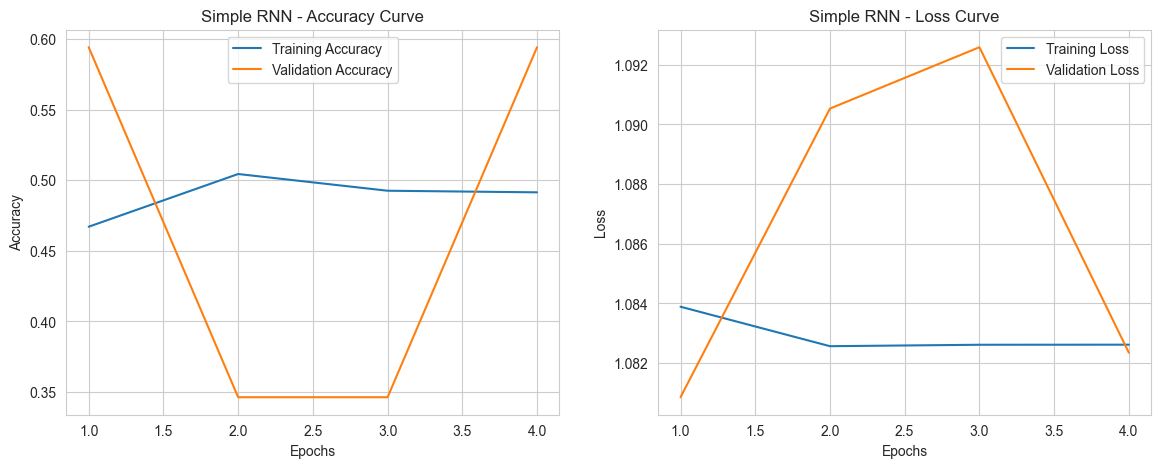

              precision    recall  f1-score   support

    negative       0.50      0.00      0.00       408
     neutral       0.00      0.00      0.00        51
    positive       0.62      1.00      0.77       761

    accuracy                           0.62      1220
   macro avg       0.37      0.33      0.26      1220
weighted avg       0.56      0.62      0.48      1220



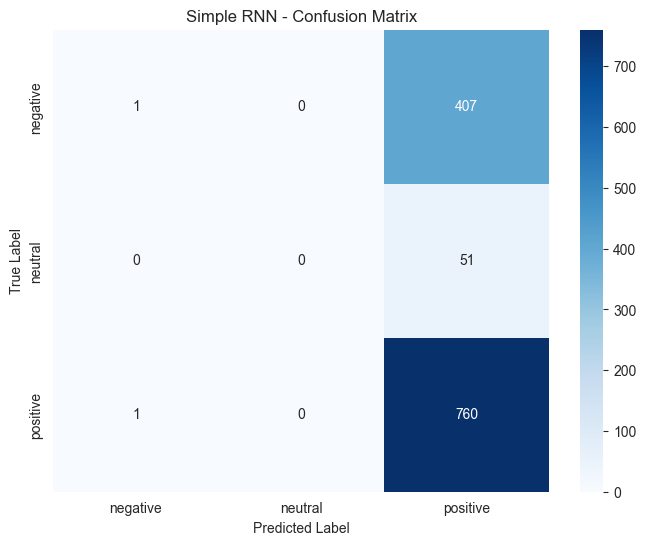

In [25]:
plot_training_history(history_earlystopping_rnn, "Simple RNN")
evaluate_model(model_rnn_simple, X_test, y_test, label_encoder, "Simple RNN")


### Modelo RNN Simple

- Recall: 100% para la clase positiva y 0% para las clases negativa y neutral, lo que indica que el modelo predice todos los comentarios como positivos, ignorando completamente las otras clases o que no es capaz de diferenciarlas.

- Accuracy = 0,62 coincide con la cantidad de comentarios positivos del dataset de prueba (62%). El modelo no ha aprendido a distinguir entre las clases y simplemente predice la clase mayoritaria (positivo) para maximizar la precisión global.


- El modelo está sesgado a favor de la clase positiva que es la clase mayoritaria, de esta forma obtiene una alta precisión en esa clase, pero falla completamente en las otras dos clases, pero esto en la práctica no es útil para un análisis de sentimientos equilibrado. A primera vista, un accuracy del 62% puede parecer aceptable, pero al analizar las métricas de precisión y recall, queda claro que el modelo no está funcionando adecuadamente para las clases minoritarias (negativo y neutral). El valor de f1-score macro avg es de 0.26 lo que indica que este modelo es incapaz de distinguir entre clases y se ignoran los comentarios negativos y neutrales.


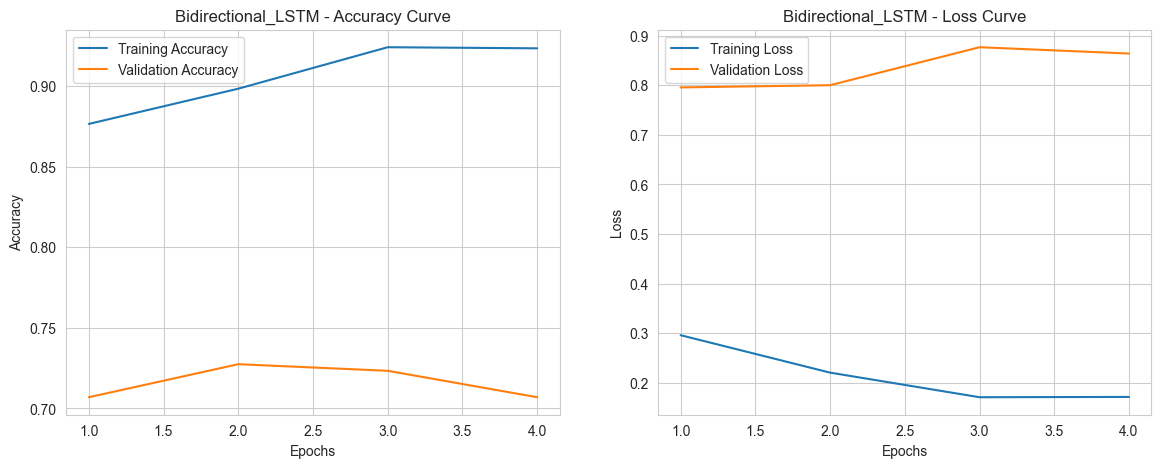

              precision    recall  f1-score   support

    negative       0.55      0.78      0.65       408
     neutral       0.50      0.55      0.52        51
    positive       0.87      0.67      0.75       761

    accuracy                           0.70      1220
   macro avg       0.64      0.67      0.64      1220
weighted avg       0.75      0.70      0.71      1220



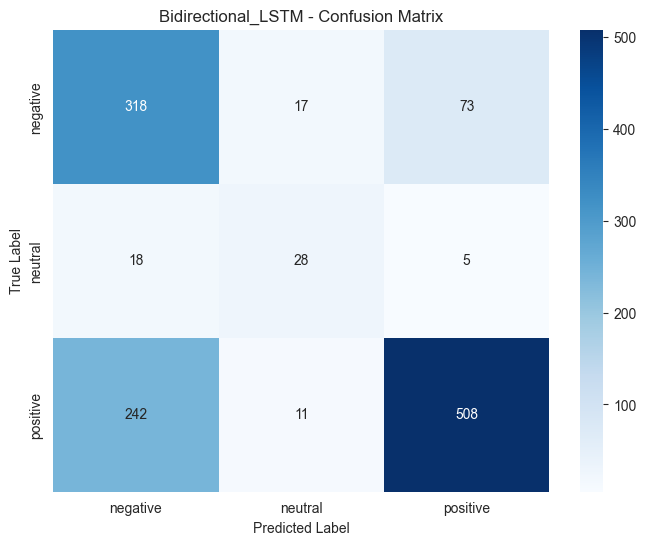

In [26]:

plot_training_history(history_earlystopping_lstm, "Bidirectional_LSTM")
evaluate_model(model_lstm, X_test, y_test, label_encoder, "Bidirectional_LSTM")


### Modelo Bidirectional_LSTM


- Recall: Vemos unos valores mucho más equilibrados entre las 3 clases, obteniendo un 0.67 para la clase positiva, un 0.78 para la negativa y 0.55 para la clase neutral, lo que indica que el modelo es capaz de identificar correctamente una proporción significativa de comentarios en cada categoría. Este modelo es mucho mejor que la RNN Simple debido a que podemos distinguir entre las 3 clases y no se limita a predecir siempre la clase mayoritaria.

- Accuracy: Un valor de 0,70 indica que el modelo es capaz de clasificar correctamente el 70% de los comentarios en el conjunto de prueba, lo que representa una mejora significativa respecto a la RNN Simple (que simplemente predecía siempre la clase mayoritaria). Además, gracias al recall vemos que las predicciones están equilibradas entre las 3 clases.

- Precisión: El modelo acierta el 87% de las veces en la clase positiva, el 55% en la clase negativa y el 50% en la clase neutral, lo que indica que las predicciones positivas son bastante fiables, mientras que hay un mayor margen de error en las clases negativa y neutral. Somos conscientes de que la clase neutral es la más difícil de predecir debido a su baja representación en el dataset y pasa algo parecido con la clase negativa, aunque realizando el ajuste de pesos de clase hemos mejorado su rendimiento.

- F1-score: El valor de f1-score macro avg es de 0.64, lo que indica un buen equilibrio entre precisión y recall en todas las clases. Esto sugiere que el modelo no solo es preciso en sus predicciones, sino que también es capaz de identificar una proporción significativa de comentarios en cada categoría. Hay que destacar el valor 0.52 sobre la clase neutral, ya que esta clase representa solo el 4.2% del dataset y es la más difícil de predecir, por lo que un f1-score de 0.52 es un buen resultado considerando el desbalance de clases.



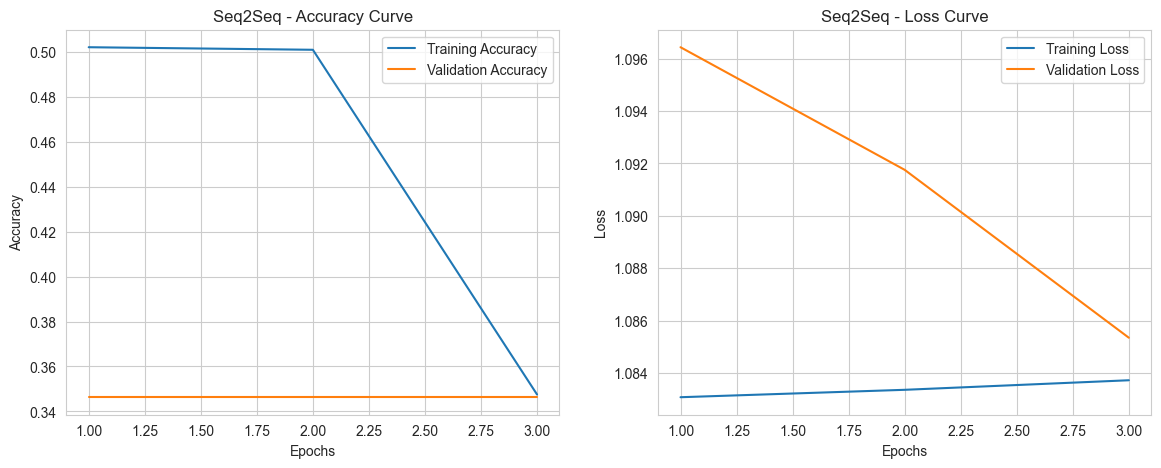

              precision    recall  f1-score   support

    negative       0.33      1.00      0.50       408
     neutral       0.00      0.00      0.00        51
    positive       0.00      0.00      0.00       761

    accuracy                           0.33      1220
   macro avg       0.11      0.33      0.17      1220
weighted avg       0.11      0.33      0.17      1220



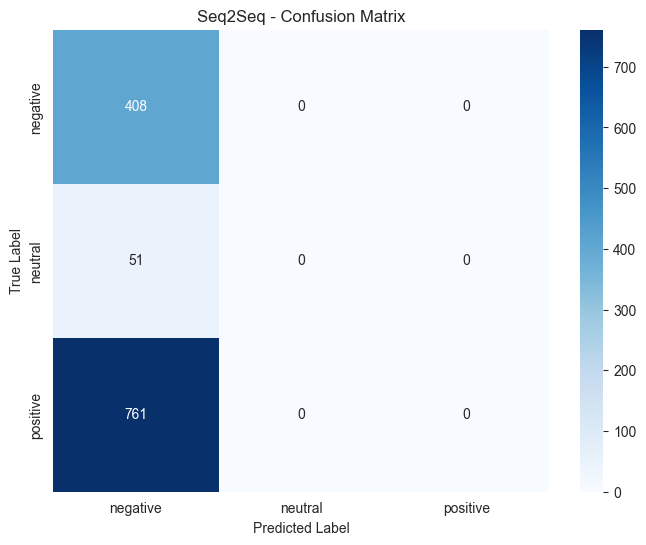

In [27]:

plot_training_history(history_earlystopping_seq2seq, "Seq2Seq")
evaluate_model(model_seq2seq, X_test, y_test, label_encoder, "Seq2Seq")

### Modelo Seq2Seq


- Recall: Observamos el comportamiento contrario a la RNN Simple, con un recall del 100% para la clase negativa y 0% para las clases positiva y neutral, lo que indica que el modelo predice todos los comentarios como negativos, ignorando completamente las otras clases o que no es capaz de diferenciarlas. Una posible causa de este comportamiento es que el encoder comprime toda la información del comentario en un solo vector de 64 números, lo que puede ser insuficiente para capturar la complejidad y matices del lenguaje en los comentarios de YouTube, especialmente cuando se trata de análisis de sentimientos donde las sutilezas son importantes.

- Accuracy: Un valor de 0,33 es lo mismo que el valor del azar en un problema de clasificación con 3 clases. Además, coincide con la proporción de comentarios negativos de los datos de test (408 de 1220).

- Precisión: La precisión es del 33% para la clase negativa y 0% para las clases positiva y neutral, el modelo no discrimina, acierta el 33% de las veces en la clase negativa pero falla completamente en las otras dos clases.

- F1-score: El valor de f1-score macro avg es de 0.17 indicando que el modelo no es útil. Como la fórmula es la media de f1-score de las 3 clases, obtenemos (0.5+0+0)/3=0.17, esto significa que el modelo falla completamente en las clases positiva y neutral y solo acierta en la clase negativa.


La arquitectura creada para el modelo Seq2Seq no es capaz de converger hacia una solución óptima para resolver el problema de clasificación de sentimientos en este dataset específico y sufre del fenómeno Model Collapse (Colapso del Modelo), donde el modelo aprende a predecir siempre la misma clase (negativa en este caso) independientemente de la entrada.

## Conclusión Final, Lecciones Aprendidas y Mejoras Futuras

Después de evaluar los modelos RNN Simple, Bidirectional LSTM y Seq2Seq, podemos concluir que el modelo Bidirectional LSTM ha demostrado ser el más efectivo para la tarea de análisis de sentimientos en los comentarios de YouTube sobre los Juegos Olímpicos de París 2024. Este modelo ha logrado un equilibrio adecuado entre precisión y recall en todas las clases, superando significativamente a los otros dos modelos.

### Lecciones Aprendidas
Complejidad $\neq$ Eficiencia: Las arquitecturas más complejas no siempre garantizan mejores resultados. El modelo Seq2Seq, a pesar de su sofisticación, no logró superar el rendimiento de la Bidirectional LSTM (Many to One), lo que destaca la importancia de seleccionar la arquitectura adecuada para el problema específico.

Observando la superioridad del modelo Bidirectional LSTM, hay que destacar su capacidad sobre la importancia del contexto, al realizar un estudio de análisis de sentimientos, es crucial capturar el contexto completo del comentario, tanto de izquierda a derecha como de derecha a izquierda, para entender matices como ironías o negaciones. Esta capacidad de retener información a largo plazo y manejar dependencias complejas en el lenguaje es fundamental para lograr una clasificación precisa.

La aplicación de pesos de clase ha sido esencial para mitigar el sesgo hacia la clase mayoritaria (positivo) y mejorar la capacidad del modelo para clasificar correctamente las clases minoritarias (negativo y neutral). Esto ha contribuido a un rendimiento más equilibrado y justo en la clasificación de sentimientos.

### Mejoras Futuras


Podemos hacer uso de transformers preentrenados como BERT, RoBERTa o GPT, que han demostrado un rendimiento superior en tareas de procesamiento de lenguaje natural. Estos modelos pueden capturar contextos complejos y matices del lenguaje de manera más efectiva que las RNN tradicionales. Estos modelos pueden ser afinados (fine-tuned) para nuestro conjunto de datos específico, lo que podría mejorar significativamente la precisión y la capacidad de generalización del modelo.

En vez de hacer uso de Embeddings entrenados desde cero para este problema, podemos hacer uso de word embeddings preentrenados como GloVe o Word2Vec. Estos embeddings han sido entrenados en grandes corpus de texto y capturan relaciones semánticas entre palabras de manera más efectiva. Al utilizar estos embeddings, podemos mejorar la representación de las palabras en nuestro modelo y potencialmente aumentar su rendimiento.


Otra mejora es intentar equilibrar el dataset mediante técnicas de oversampling (aumentar la cantidad de datos en las clases minoritarias) o undersampling (reducir la cantidad de datos en la clase mayoritaria). Esto ayudaría a mitigar el desbalance de clases y mejorar la capacidad del modelo para aprender patrones útiles en todas las categorías de sentimiento.

También se puede hacer uso de Keras Tuner para automatizar la búsqueda de hiperparámetros óptimos para los modelos. Esto incluiría ajustar el número de unidades en las capas LSTM, la tasa de dropout, el tamaño del batch y otros parámetros clave que pueden influir en el rendimiento del modelo. Al optimizar estos hiperparámetros, podríamos mejorar aún más la precisión y la capacidad de generalización del modelo.